KeyboardInterrupt: 

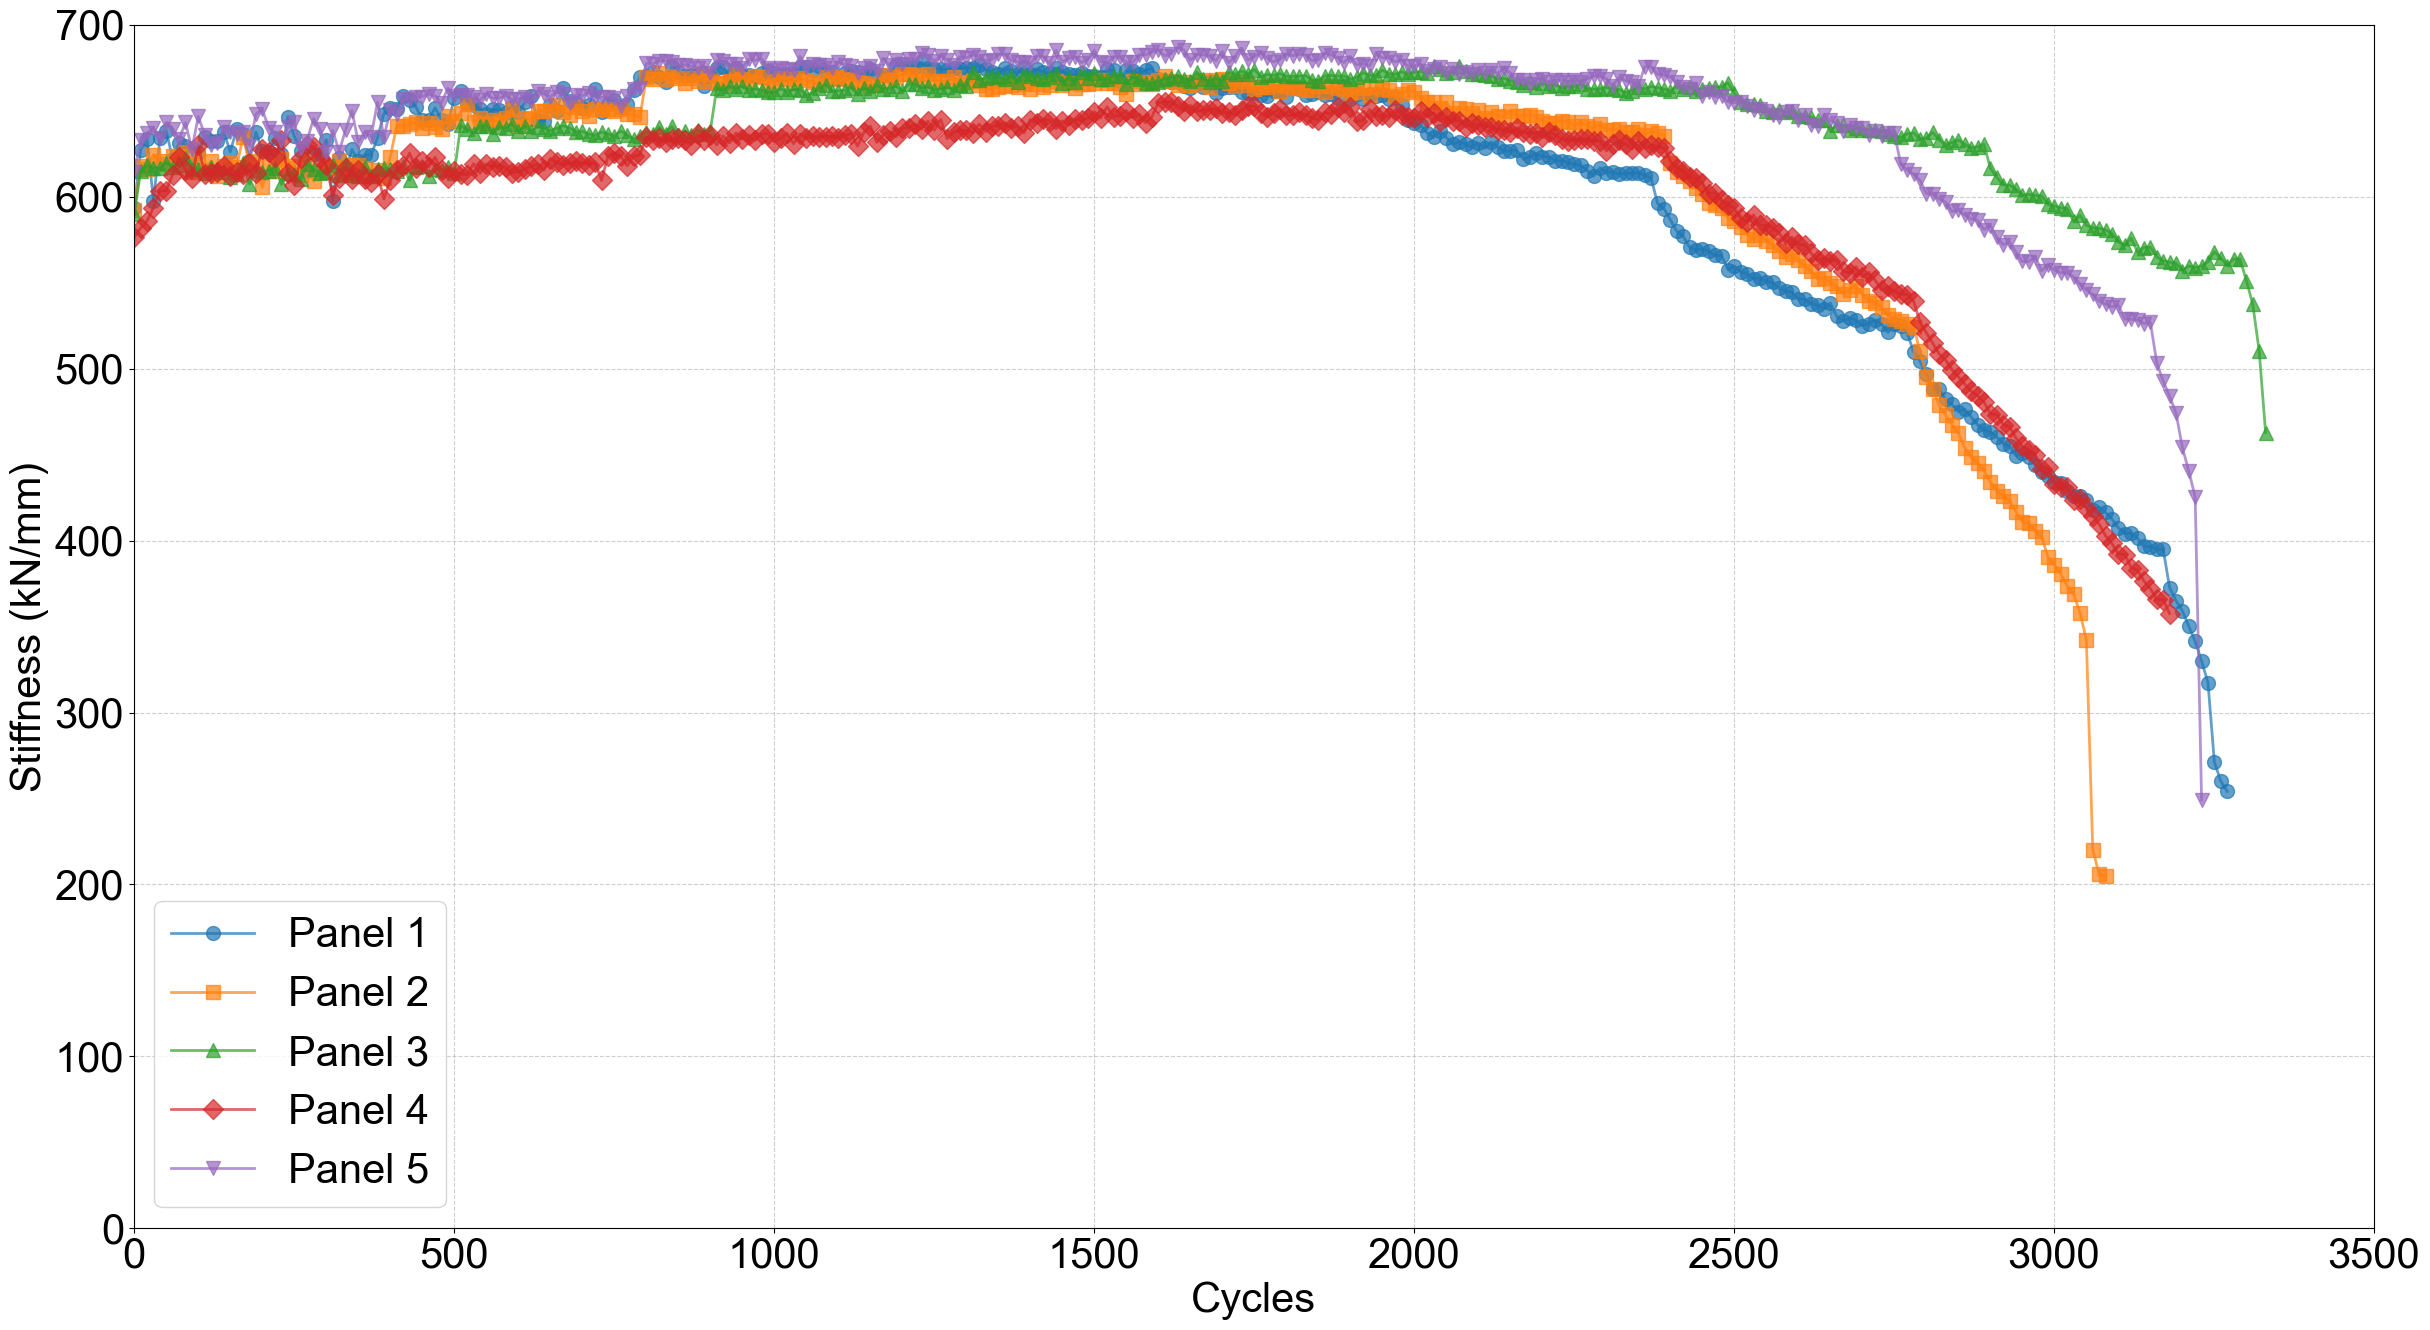

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- MODIFIED: Settings for High-Resolution Plot ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 30 # General font size for ticks, etc.

def process_stiffness_data(file_path):
    """Loads, cleans, and prepares stiffness data from a single file."""
    df = pd.read_csv(file_path)
    
    # Convert columns to numeric, turning errors into NaN
    df['Load'] = pd.to_numeric(df['Load'], errors='coerce')
    df['Stiffness'] = pd.to_numeric(df['Stiffness'], errors='coerce')
    
    # --- DATA CLEANING ---
    df.dropna(inplace=True)
    df = df[df['Stiffness'] > 0]
    df = df[df['Load'] >= 0]
    
    # Outlier Removal using the IQR method
    if not df.empty:
        Q1 = df['Stiffness'].quantile(0.01)
        Q3 = df['Stiffness'].quantile(0.99)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Keep only the data within the bounds
        df = df[(df['Stiffness'] >= lower_bound) & (df['Stiffness'] <= upper_bound)]

    if df.empty:
        return None, None
        
    # Use the dataframe index as the cycle number
    df.reset_index(drop=True, inplace=True)
    df['Cycle'] = df.index + 1
    
    # Calculate initial stiffness from the first 10 clean data points
    initial_stiffness = df['Stiffness'].head(10).mean()
    
    return df, initial_stiffness

# --- Main Script ---
# List of files to process
files = [
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD3.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD4.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD5.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD6.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD7.csv"
]

all_data = []
initial_stiffnesses = []

for file in files:
    if os.path.exists(file):
        specimen_name = os.path.basename(file).replace('.csv', '').replace('MTSStiffness_exp_', '')
        df, init_stiff = process_stiffness_data(file)
        
        if df is not None:
            df['Specimen'] = specimen_name
            all_data.append(df)
            initial_stiffnesses.append((specimen_name, init_stiff))
    else:
        print(f"File not found: {file}")

if not all_data:
    print("\nNo data available to plot after cleaning.")
else:
    combined_df = pd.concat(all_data, ignore_index=True)

    # --- Plotting Section ---
    # --- MODIFIED: Set new figure size ---
    plt.figure(figsize=(25, 14))

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    markers = ['o', 's', '^', 'D', 'v']
    
    unique_specimens = combined_df['Specimen'].unique()
    for i, (specimen, color, marker) in enumerate(zip(unique_specimens, colors, markers), start=1):
        specimen_data = combined_df[combined_df['Specimen'] == specimen]
        filtered_data = specimen_data.iloc[::10]
        
        panel_label = f"Panel {i}"
        
        # --- MODIFIED: Set new line width and marker size ---
        plt.plot(filtered_data['Cycle'], filtered_data['Stiffness'], 
                 marker=marker, 
                 linestyle='-', 
                 color=color, 
                 alpha=0.7, 
                 markersize=10,
                 linewidth=2,
                 label=panel_label)

    # --- MODIFIED: Set new font sizes for labels and ticks ---
    plt.xlabel('Cycles', fontsize=30)
    plt.ylabel('Stiffness (kN/mm)', fontsize=30)
    plt.xlim(0, 3500)
    plt.ylim(0,700)
    plt.tick_params(axis='both', which='major', labelsize=30)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=30)
    plt.tight_layout()

    # --- Saving the Figure ---
    output_path = "Data/Stiffness_Reduction/Figure_Stiffness_vs_Cycles_High_Res.png"
    # --- MODIFIED: Set new DPI ---
    plt.savefig(output_path, dpi=650, bbox_inches='tight')
    print(f"\nHigh-resolution plot saved to: {output_path}")

    plt.show()

--- Generating Stiffness vs. Load Plot ---
Info: For FOD3, trimming 27 final rows due to load decrease.
Info: For FOD4, trimming 26 final rows due to load decrease.
Info: For FOD7, trimming 7 final rows due to load decrease.

New high-resolution plot saved to: Data/Stiffness_Reduction/Figure_Stiffness_vs_Load_High_Res.png


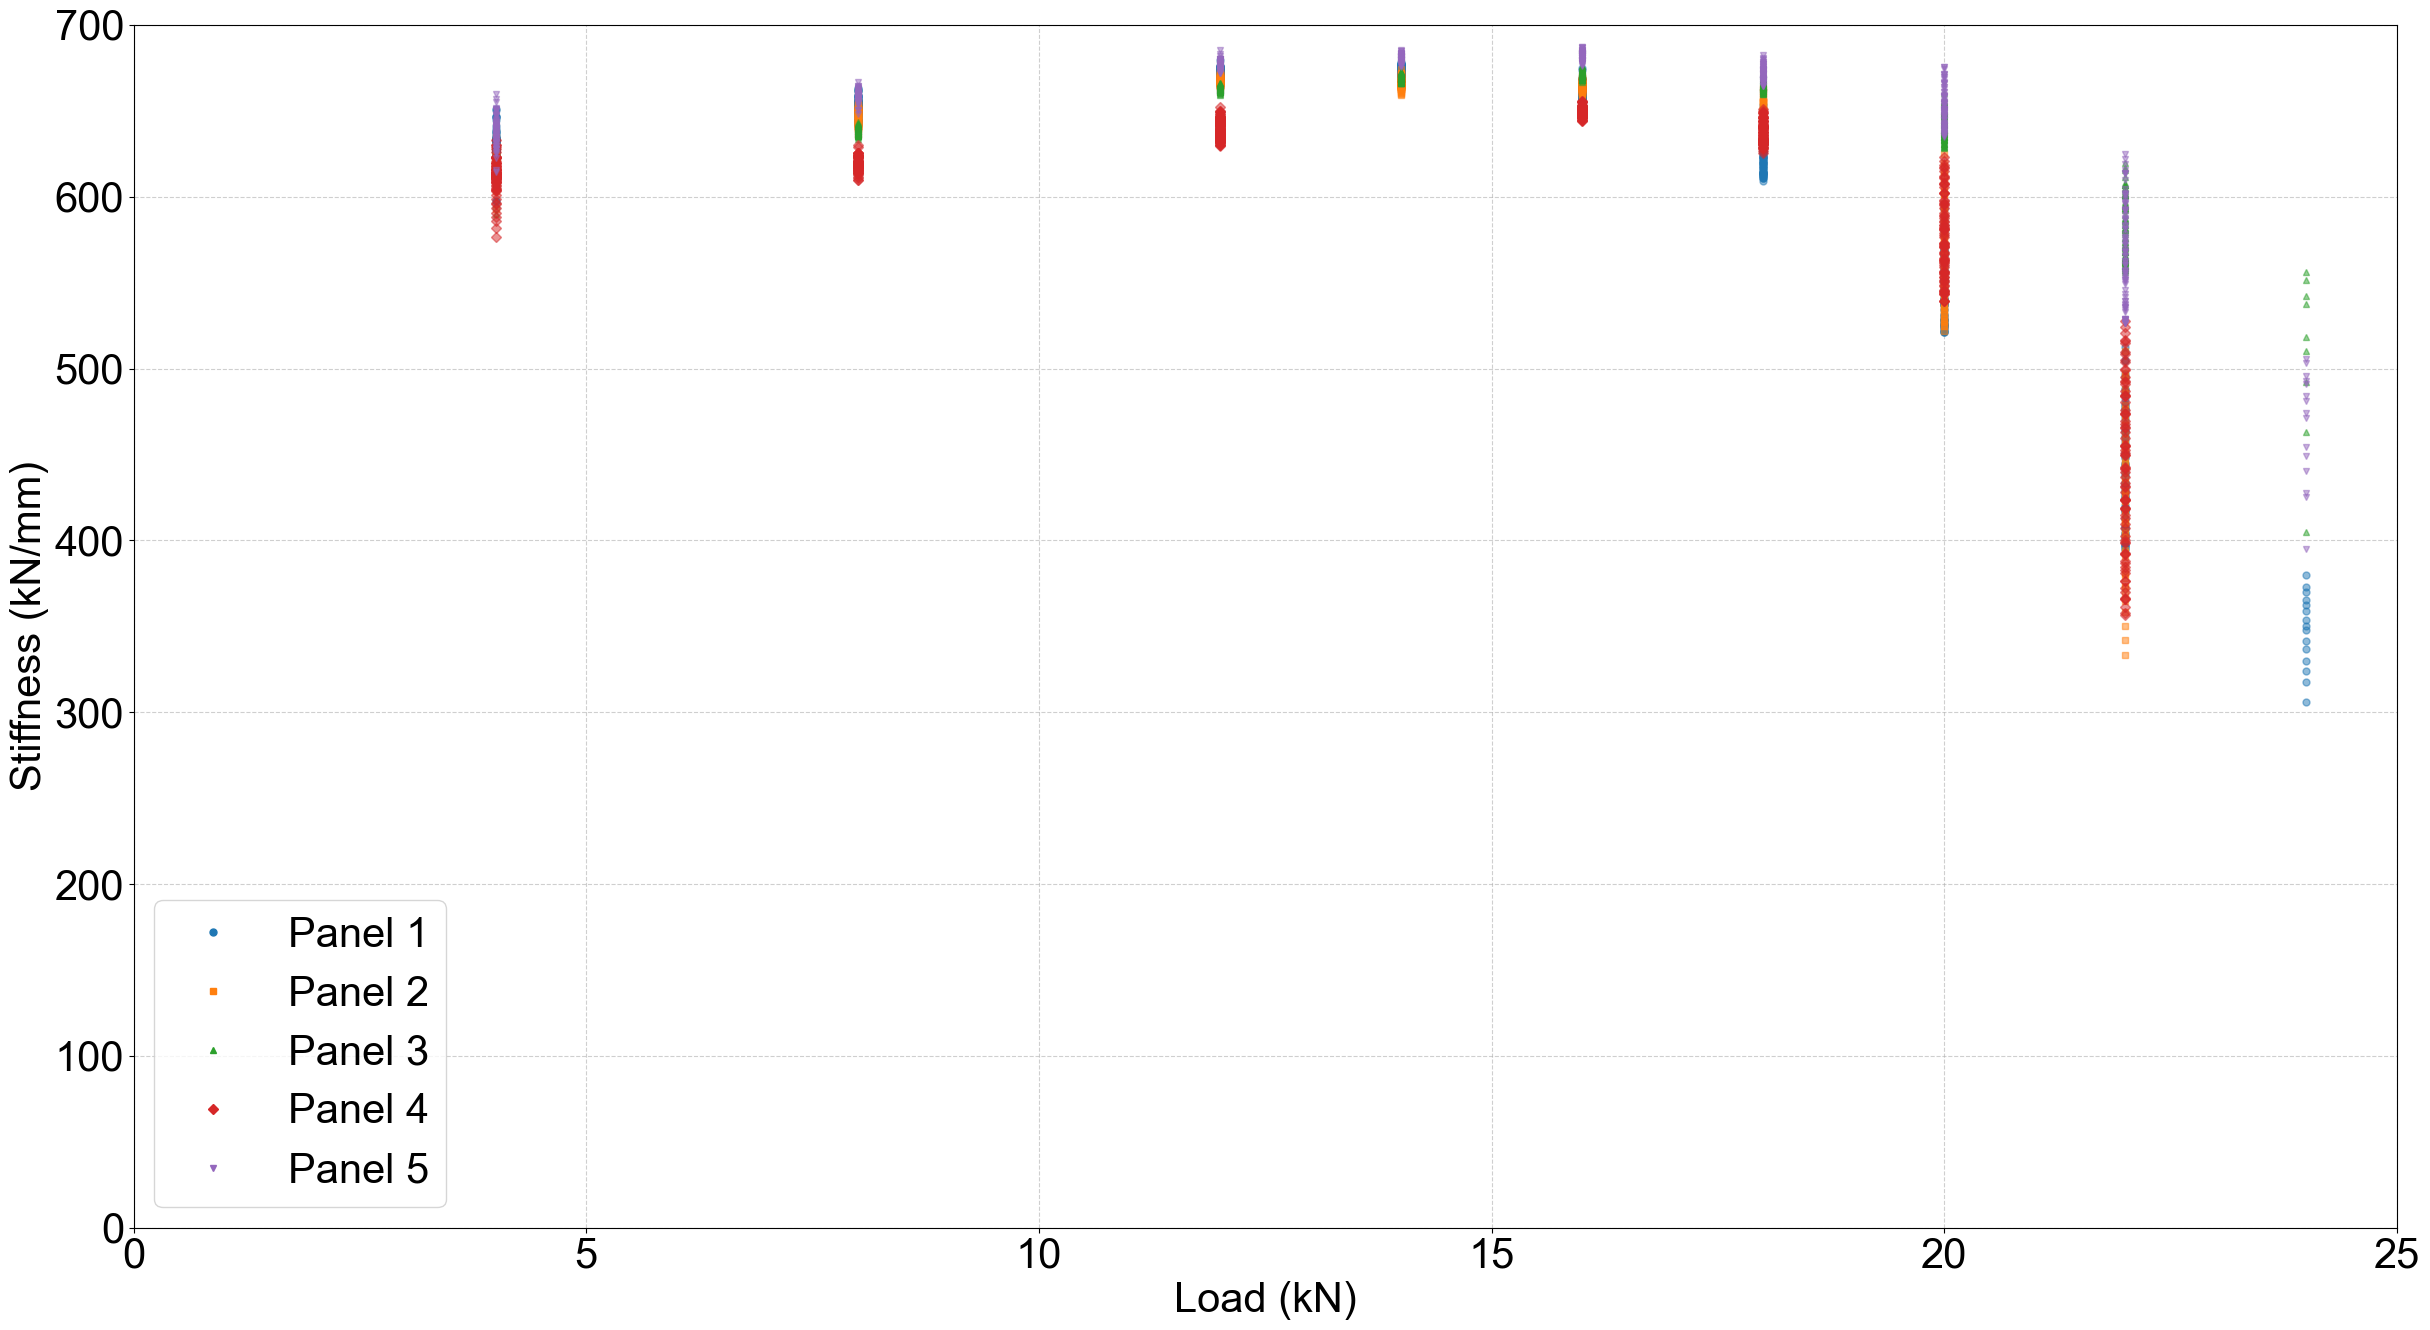

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- New Code Cell for Stiffness vs. Load Plot ---

print("--- Generating Stiffness vs. Load Plot ---")

all_load_filtered_data = []

# We assume the 'process_stiffness_data' function and 'files' list are available 
# from a previous cell.

# 1. Process each file to filter for monotonically increasing load
for file in files:
    if os.path.exists(file):
        specimen_name = os.path.basename(file).replace('.csv', '').replace('MTSStiffness_exp_', '')
        
        # Use the existing function to get the initially cleaned data
        df, _ = process_stiffness_data(file)
        
        if df is not None:
            # --- New Filtering Logic for Load Decrease ---
            cum_max_load = df['Load'].cummax()
            decreasing_points = df['Load'] < cum_max_load
            
            original_rows = len(df)
            
            if decreasing_points.any():
                first_drop_index = decreasing_points.idxmax()
                df_filtered = df.iloc[:first_drop_index].copy()
                print(f"Info: For {specimen_name}, trimming {original_rows - len(df_filtered)} final rows due to load decrease.")
            else:
                df_filtered = df.copy() 
            
            df_filtered['Specimen'] = specimen_name
            all_load_filtered_data.append(df_filtered)

# 2. Plot the newly filtered data if any exists
if not all_load_filtered_data:
    print("\nNo data available to plot after filtering for load decrease.")
else:
    combined_load_df = pd.concat(all_load_filtered_data, ignore_index=True)
    
    # --- Plotting Section ---
    plt.figure(figsize=(25, 14))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    markers = ['o', 's', '^', 'D', 'v']
    
    unique_specimens = combined_load_df['Specimen'].unique()
    for i, (specimen, color, marker) in enumerate(zip(unique_specimens, colors, markers), start=1):
        specimen_data = combined_load_df[combined_load_df['Specimen'] == specimen]
        filtered_plot_data = specimen_data.iloc[::5]
        panel_label = f"Panel {i}"
        
        plt.plot(filtered_plot_data['Load'], filtered_plot_data['Stiffness'], 
                 marker=marker, 
                 linestyle='none', 
                 alpha=0.5, 
                 markersize=5, 
                 label=panel_label,
                 color=color)
    
    # Apply high-resolution formatting
    plt.xlabel('Load (kN)', fontsize=30)
    plt.ylabel('Stiffness (kN/mm)', fontsize=30)
    plt.tick_params(axis='both', which='major', labelsize=30)
    
    plt.ylim(0, 700)
    plt.xlim(0, 25)
    plt.xticks(np.arange(0, 25 + 1, 5)) 
    
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # --- MODIFIED: Set legend location ---
    legend = plt.legend(fontsize=30, loc='lower left')
    # Loop through the legend handles and set their alpha to 1 (100% opaque)
    # Corrected line for modern Matplotlib
    for handle in legend.legend_handles:
        handle.set_alpha(1)
    
    plt.tight_layout()
    
    # Save the new figure
    output_path_load = "Data/Stiffness_Reduction/Figure_Stiffness_vs_Load_High_Res.png"
    plt.savefig(output_path_load, dpi=650, bbox_inches='tight')
    print(f"\nNew high-resolution plot saved to: {output_path_load}")
    
    plt.show()

Calculating load cluster ranges from: Data/Stiffness_Reduction/MTSStiffness_exp_FOD5.csv


C:\Users\Giannis\AppData\Local\Temp\ipykernel_18140\1372661459.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('cividis', len(load_cluster_ranges))



High-resolution plot with updated legend and colors saved to: Data/Stiffness_Reduction/Figure_Stiffness_vs_Cycles_Load_Clusters.png


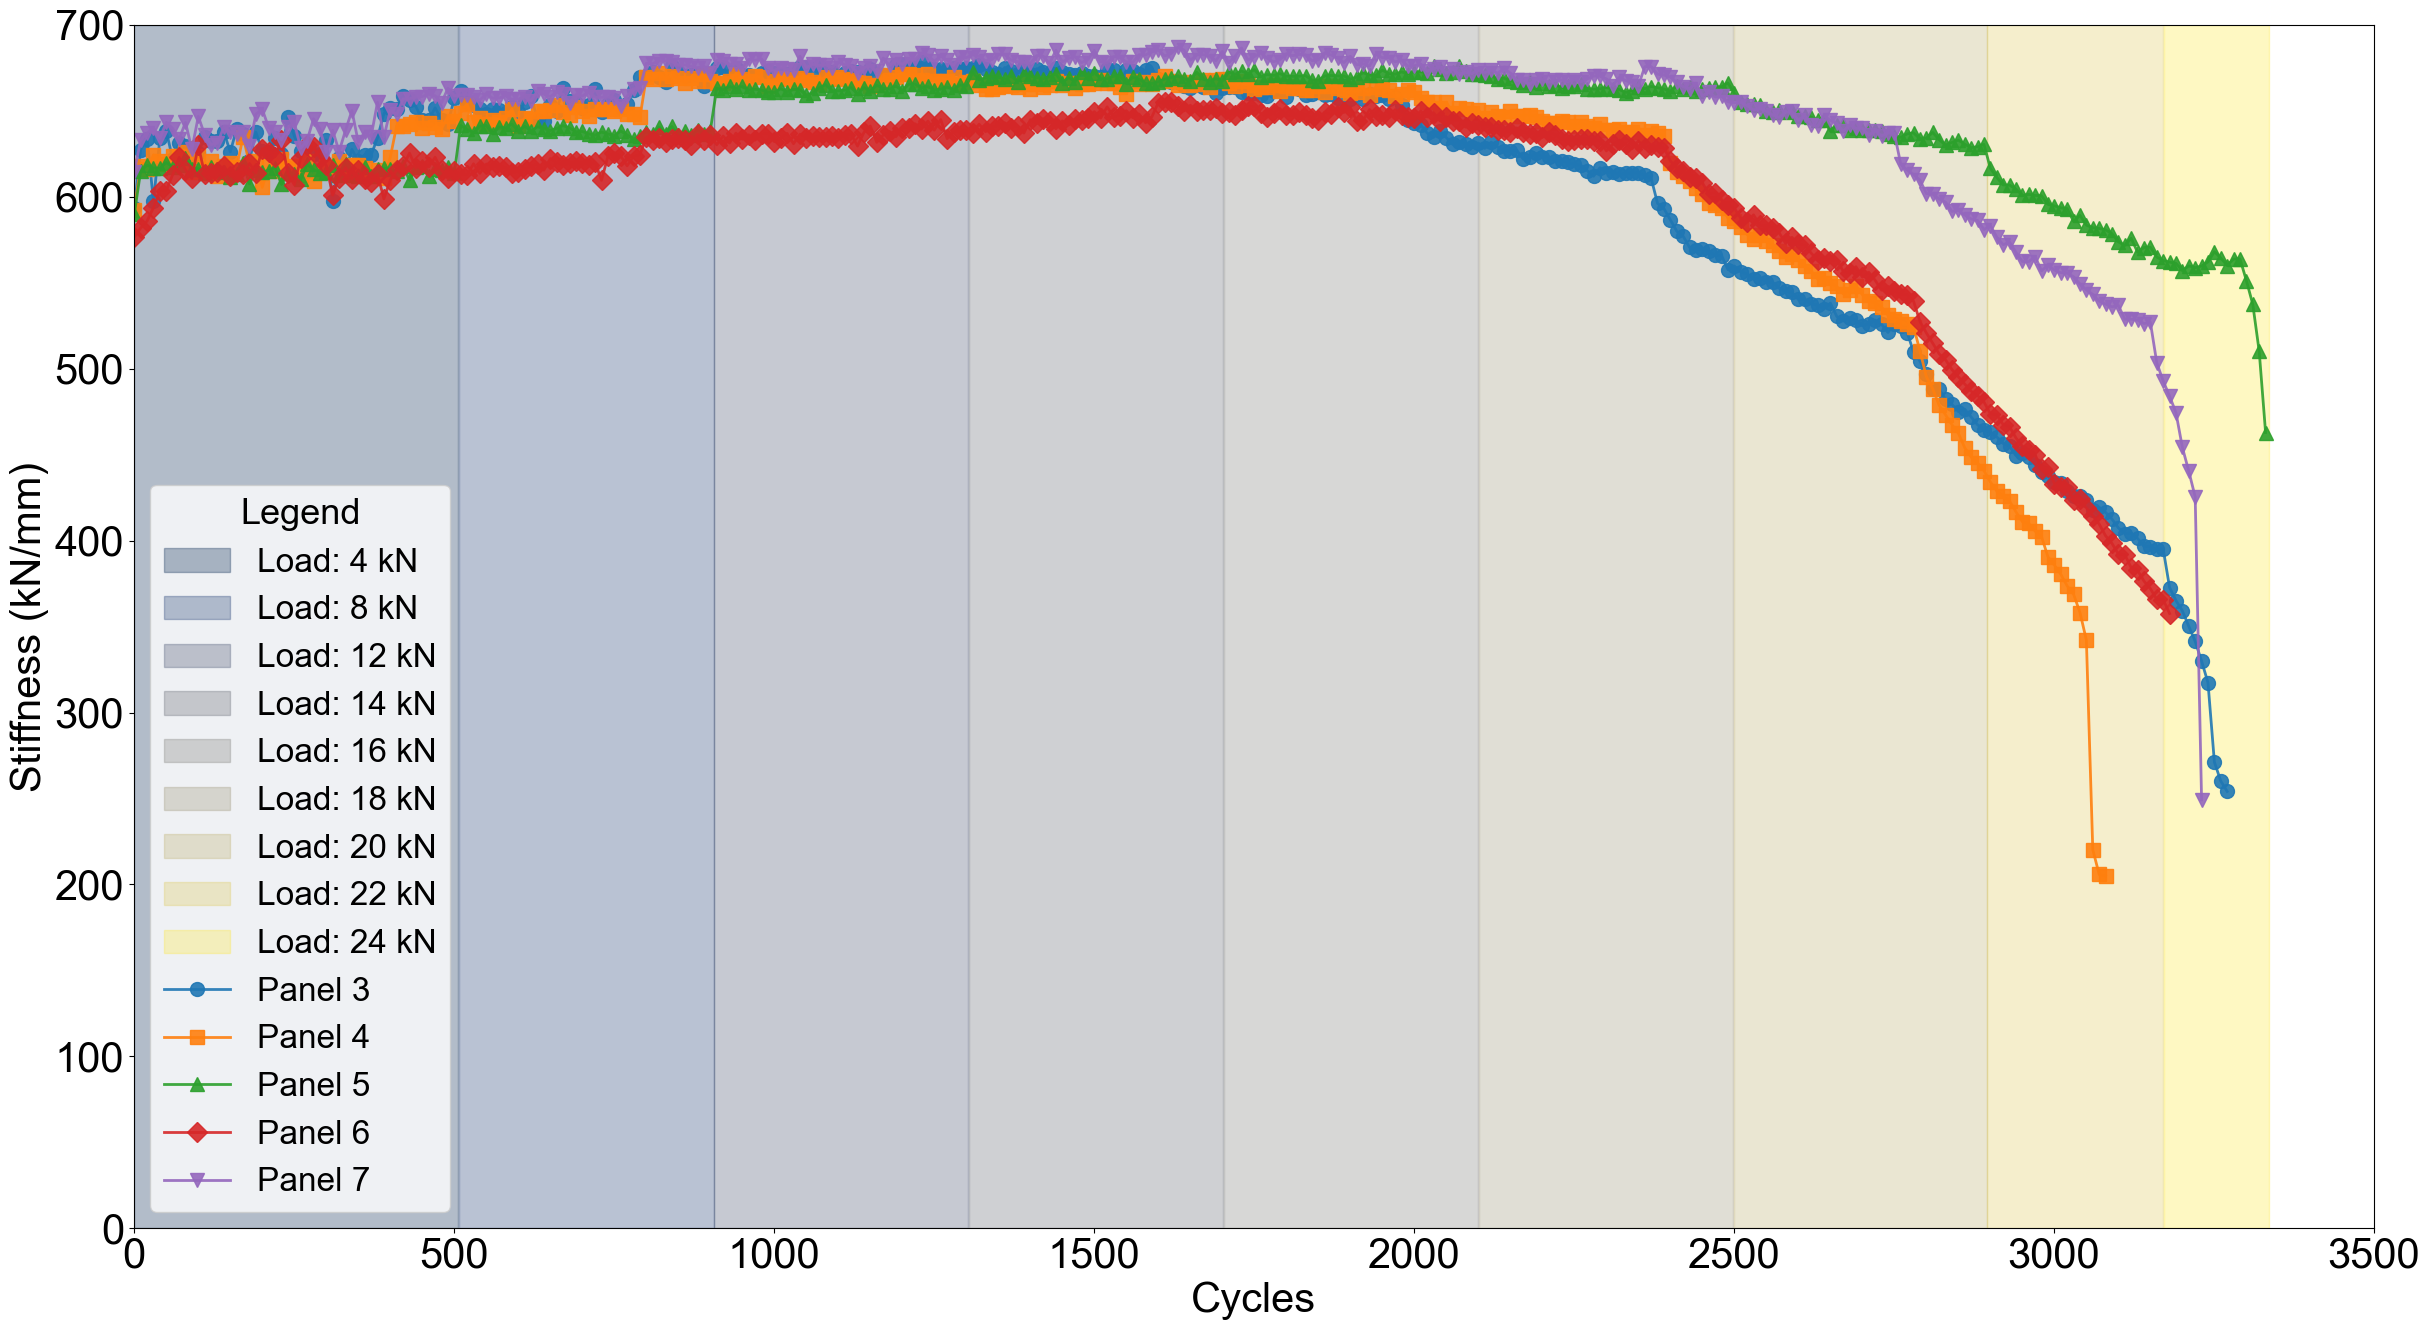

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Settings for High-Resolution Plot ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 30 # General font size for ticks, etc.

def process_stiffness_data(file_path):
    """Loads, cleans, and prepares stiffness data from a single file."""
    df = pd.read_csv(file_path)
    
    # Convert columns to numeric, turning errors into NaN
    df['Load'] = pd.to_numeric(df['Load'], errors='coerce')
    df['Stiffness'] = pd.to_numeric(df['Stiffness'], errors='coerce')
    
    # --- DATA CLEANING ---
    df.dropna(inplace=True)
    df = df[df['Stiffness'] > 0]
    df = df[df['Load'] >= 0]
    
    # Outlier Removal using the IQR method
    if not df.empty:
        Q1 = df['Stiffness'].quantile(0.01)
        Q3 = df['Stiffness'].quantile(0.99)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df = df[(df['Stiffness'] >= lower_bound) & (df['Stiffness'] <= upper_bound)]

    if df.empty:
        return None, None
        
    # Use the dataframe index as the cycle number
    df.reset_index(drop=True, inplace=True)
    df['Cycle'] = df.index + 1
    
    initial_stiffness = df['Stiffness'].head(10).mean()
    
    return df, initial_stiffness

# --- Main Script ---
# List of files for the main plot
files = [
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD3.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD4.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD5.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD6.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD7.csv"
]

all_data = []
# Load data for all panels for line plotting
for file in files:
    if os.path.exists(file):
        specimen_name = os.path.basename(file).replace('.csv', '').replace('MTSStiffness_exp_', '')
        df, _ = process_stiffness_data(file)
        if df is not None:
            df['Specimen'] = specimen_name
            all_data.append(df)
    else:
        print(f"File not found: {file}")

if not all_data:
    print("\nNo data available to plot after cleaning.")
else:
    combined_df = pd.concat(all_data, ignore_index=True)

    # --- NEW: Calculate Load Cluster ranges based SOLELY on FOD5 data ---
    fod5_file_path = "Data/Stiffness_Reduction/MTSStiffness_exp_FOD5.csv"
    load_cluster_ranges = []
    
    if os.path.exists(fod5_file_path):
        print(f"Calculating load cluster ranges from: {fod5_file_path}")
        df_fod5, _ = process_stiffness_data(fod5_file_path)
        
        # The 9 distinct load steps to find
        load_steps = [4, 8, 12, 14, 16, 18, 20, 22, 24]
        
        # Group by the 'Load' column and find the min/max cycle for each group
        cycle_ranges_by_load = df_fod5.groupby('Load')['Cycle'].agg(['min', 'max'])
        
        # Create a list of dictionaries with the start and end cycles for each load step
        for load in load_steps:
            if load in cycle_ranges_by_load.index:
                min_cycle = cycle_ranges_by_load.loc[load]['min']
                max_cycle = cycle_ranges_by_load.loc[load]['max']
                load_cluster_ranges.append({
                    'load': load,
                    'start_cycle': min_cycle,
                    'end_cycle': max_cycle
                })
    else:
        print(f"Warning: {fod5_file_path} not found. Cannot create Load clusters.")

    # --- Plotting Section ---
    fig, ax = plt.subplots(figsize=(25, 14))

    # --- MODIFIED: Draw vertical bands based on calculated Load Clusters ---
    if load_cluster_ranges:
        # --- MODIFIED: Changed color map to 'cividis' ---
        colors = plt.cm.get_cmap('cividis', len(load_cluster_ranges))
        
        for i, cluster in enumerate(load_cluster_ranges):
            ax.axvspan(cluster['start_cycle'], cluster['end_cycle'], 
                       color=colors(i), 
                       alpha=0.3, 
                       label=f"Load: {cluster['load']} kN")

    # --- Plotting the specimen data ON TOP of the bands ---
    # --- MODIFIED: Changed to Tableau color palette for better visuals ---
    specimen_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    specimen_markers = ['o', 's', '^', 'D', 'v']
    
    unique_specimens = sorted(combined_df['Specimen'].unique())
    
    for i, (specimen, color, marker) in enumerate(zip(unique_specimens, specimen_colors, specimen_markers)):
        specimen_data = combined_df[combined_df['Specimen'] == specimen]
        filtered_data = specimen_data.iloc[::10]
        
        panel_label = f"Panel {specimen.replace('FOD', '')}"
        
        ax.plot(filtered_data['Cycle'], filtered_data['Stiffness'], 
                 marker=marker, 
                 linestyle='-', 
                 color=color, 
                 alpha=0.9, 
                 markersize=10,
                 linewidth=2,
                 label=panel_label)

    # --- Plot Customization ---
    ax.set_xlabel('Cycles', fontsize=30)
    ax.set_ylabel('Stiffness (kN/mm)', fontsize=30)
    ax.set_xlim(0, 3500)
    ax.set_ylim(0, 700)
    ax.tick_params(axis='both', which='major', labelsize=30)
    

    
    # --- MODIFIED: Moved legend to the bottom left ---
    ax.legend(fontsize=24, title_fontsize=26, title='Legend', loc='lower left')
    
    plt.tight_layout()

    # --- Saving the Figure ---
    output_path = "Data/Stiffness_Reduction/Figure_Stiffness_vs_Cycles_Load_Clusters.png"
    plt.savefig(output_path, dpi=650, bbox_inches='tight')
    print(f"\nHigh-resolution plot with updated legend and colors saved to: {output_path}")

    plt.show()

--- Generating Strain vs. Cycles Plot for FOD7 (s13, s14, s15, s16) ---

New high-resolution strain plot saved to: Data/Strain/Figure_Strain_vs_Cycles_FOD7_specific_sensors_ordered.png


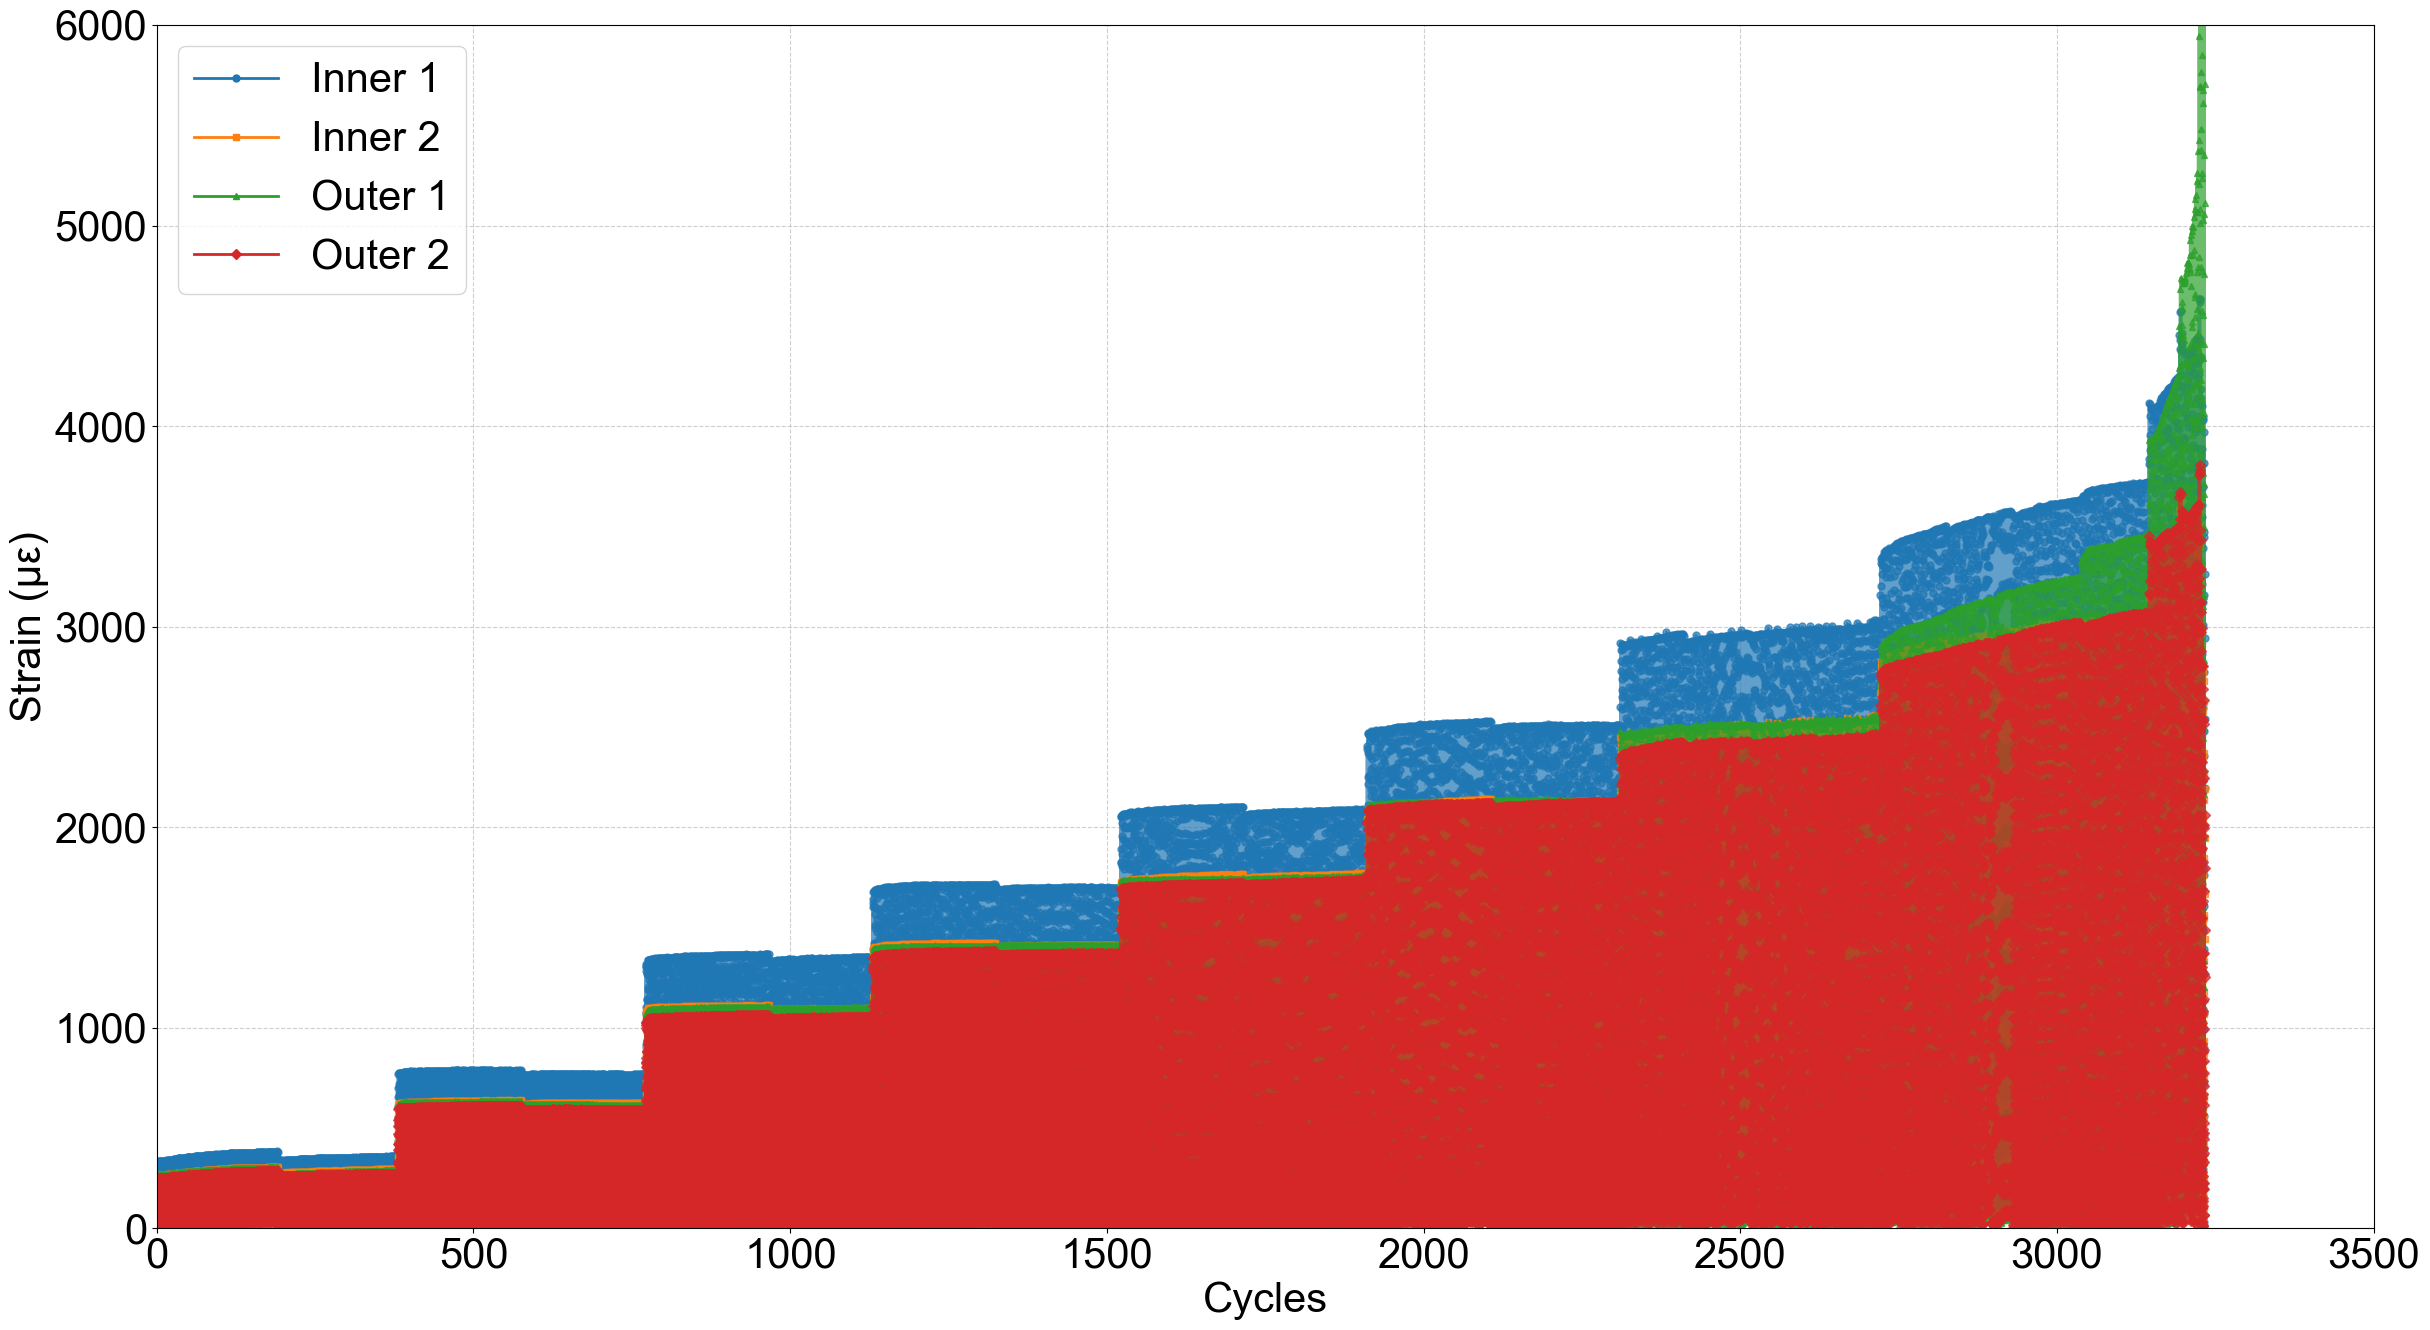

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- New Code Cell for Specific Strain Plot ---

# Define a process_stiffness_data function if it's not already in your environment
def process_stiffness_data(file_path):
    """Loads, cleans, and prepares stiffness data from a single file."""
    df = pd.read_csv(file_path)
    df['Load'] = pd.to_numeric(df['Load'], errors='coerce')
    df['Stiffness'] = pd.to_numeric(df['Stiffness'], errors='coerce')
    df.dropna(inplace=True)
    df = df[df['Stiffness'] > 0]
    df = df[df['Load'] >= 0]
    if not df.empty:
        Q1 = df['Stiffness'].quantile(0.01)
        Q3 = df['Stiffness'].quantile(0.99)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df['Stiffness'] >= lower_bound) & (df['Stiffness'] <= upper_bound)]
    if df.empty:
        return None, None
    df.reset_index(drop=True, inplace=True)
    df['Cycle'] = df.index + 1
    initial_stiffness = df['Stiffness'].head(10).mean()
    return df, initial_stiffness


print("--- Generating Strain vs. Cycles Plot for FOD7 (s13, s14, s15, s16) ---")

# Specify the target specimen and columns
specimen_to_plot = 'FOD7'
strain_columns_to_plot = ['s13', 's14', 's15', 's16'] # These are the columns to load

df_strain_processed = None

# Step 1: Get the final cycle count from the STIFFNESS file
stiffness_file = f"Data/Stiffness_Reduction/MTSStiffness_exp_{specimen_to_plot}.csv"

if not os.path.exists(stiffness_file):
    print(f"Error: Stiffness file not found for {specimen_to_plot}. Cannot proceed.")
else:
    df_stiffness, _ = process_stiffness_data(stiffness_file)
    if df_stiffness is None:
        print(f"Error: Could not process stiffness data for {specimen_to_plot}.")
    else:
        final_cycle_count = len(df_stiffness)

        # Step 2: Read and process the corresponding STRAIN file
        strain_file = f"Data/Strain/Strains_{specimen_to_plot}.csv"
        if not os.path.exists(strain_file):
            print(f"Error: Strain file not found for {specimen_to_plot}.")
        else:
            try:
                df_strain = pd.read_csv(strain_file)
                
                if not all(col in df_strain.columns for col in strain_columns_to_plot):
                    print(f"Error: Not all required columns {strain_columns_to_plot} were found in {strain_file}.")
                else:
                    df_strain_selected = df_strain[strain_columns_to_plot].copy()

                    for col in strain_columns_to_plot:
                        df_strain_selected[col] = pd.to_numeric(df_strain_selected[col], errors='coerce')

                    df_strain_selected.dropna(inplace=True)
                    
                    if df_strain_selected.empty:
                        print(f"Warning: No valid strain data in the specified columns for {specimen_to_plot}.")
                    else:
                        # Step 3: Create the 'Cycle' axis for the strain data
                        num_strain_points = len(df_strain_selected)
                        df_strain_selected['Cycle'] = np.linspace(start=1, stop=final_cycle_count, num=num_strain_points)
                        df_strain_processed = df_strain_selected

            except Exception as e:
                print(f"Error reading or processing strain file {strain_file}: {e}")

# Step 4: Plot the processed data
if df_strain_processed is None:
    print("\nNo strain data was successfully processed to create a plot.")
else:
    # --- Plotting Section ---
    plt.figure(figsize=(25, 14))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red
    markers = ['o', 's', '^', 'D']
    
    legend_labels = {
        's13': 'Outer 2',
        's14': 'Inner 2',
        's15': 'Inner 1',
        's16': 'Outer 1'
    }

    # --- MODIFIED: Create a list that defines the desired plotting order ---
    # Inner 1 (s15), Inner 2 (s14), Outer 1 (s16), Outer 2 (s13)
    plot_order = ['s15', 's14', 's16', 's13']
    
    # Loop through the new 'plot_order' list to control the sequence
    for col, color, marker in zip(plot_order, colors, markers):
        filtered_plot_data = df_strain_processed.iloc[::5]
        
        plt.plot(filtered_plot_data['Cycle'], filtered_plot_data[col], 
                 marker=marker,
                 linestyle='-',
                 alpha=0.7,
                 markersize=5,
                 linewidth=2,
                 label=legend_labels.get(col, col), # Use the custom label
                 color=color)

    # Apply high-resolution formatting
    plt.xlabel('Cycles', fontsize=30)
    plt.ylabel('Strain (με)', fontsize=30)
    plt.tick_params(axis='both', which='major', labelsize=30)
    
    plt.ylim(0, 6000)
    plt.xlim(0, 3500)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    
    legend = plt.legend(fontsize=30, loc='upper left')
    for handle in legend.legend_handles:
        handle.set_alpha(1)
        
    plt.tight_layout()
    
    # Save the new figure
    output_path_strain = f"Data/Strain/Figure_Strain_vs_Cycles_{specimen_to_plot}_specific_sensors_ordered.png"
    plt.savefig(output_path_strain, dpi=650, bbox_inches='tight')
    print(f"\nNew high-resolution strain plot saved to: {output_path_strain}")
    
    plt.show()

--- Generating Strain vs. Sample Index Plot for FOD5 (s14-s17) ---

New high-resolution strain plot saved to: Data/Strain/Figure_Strain_vs_Index_FOD5_specific_sensors.png


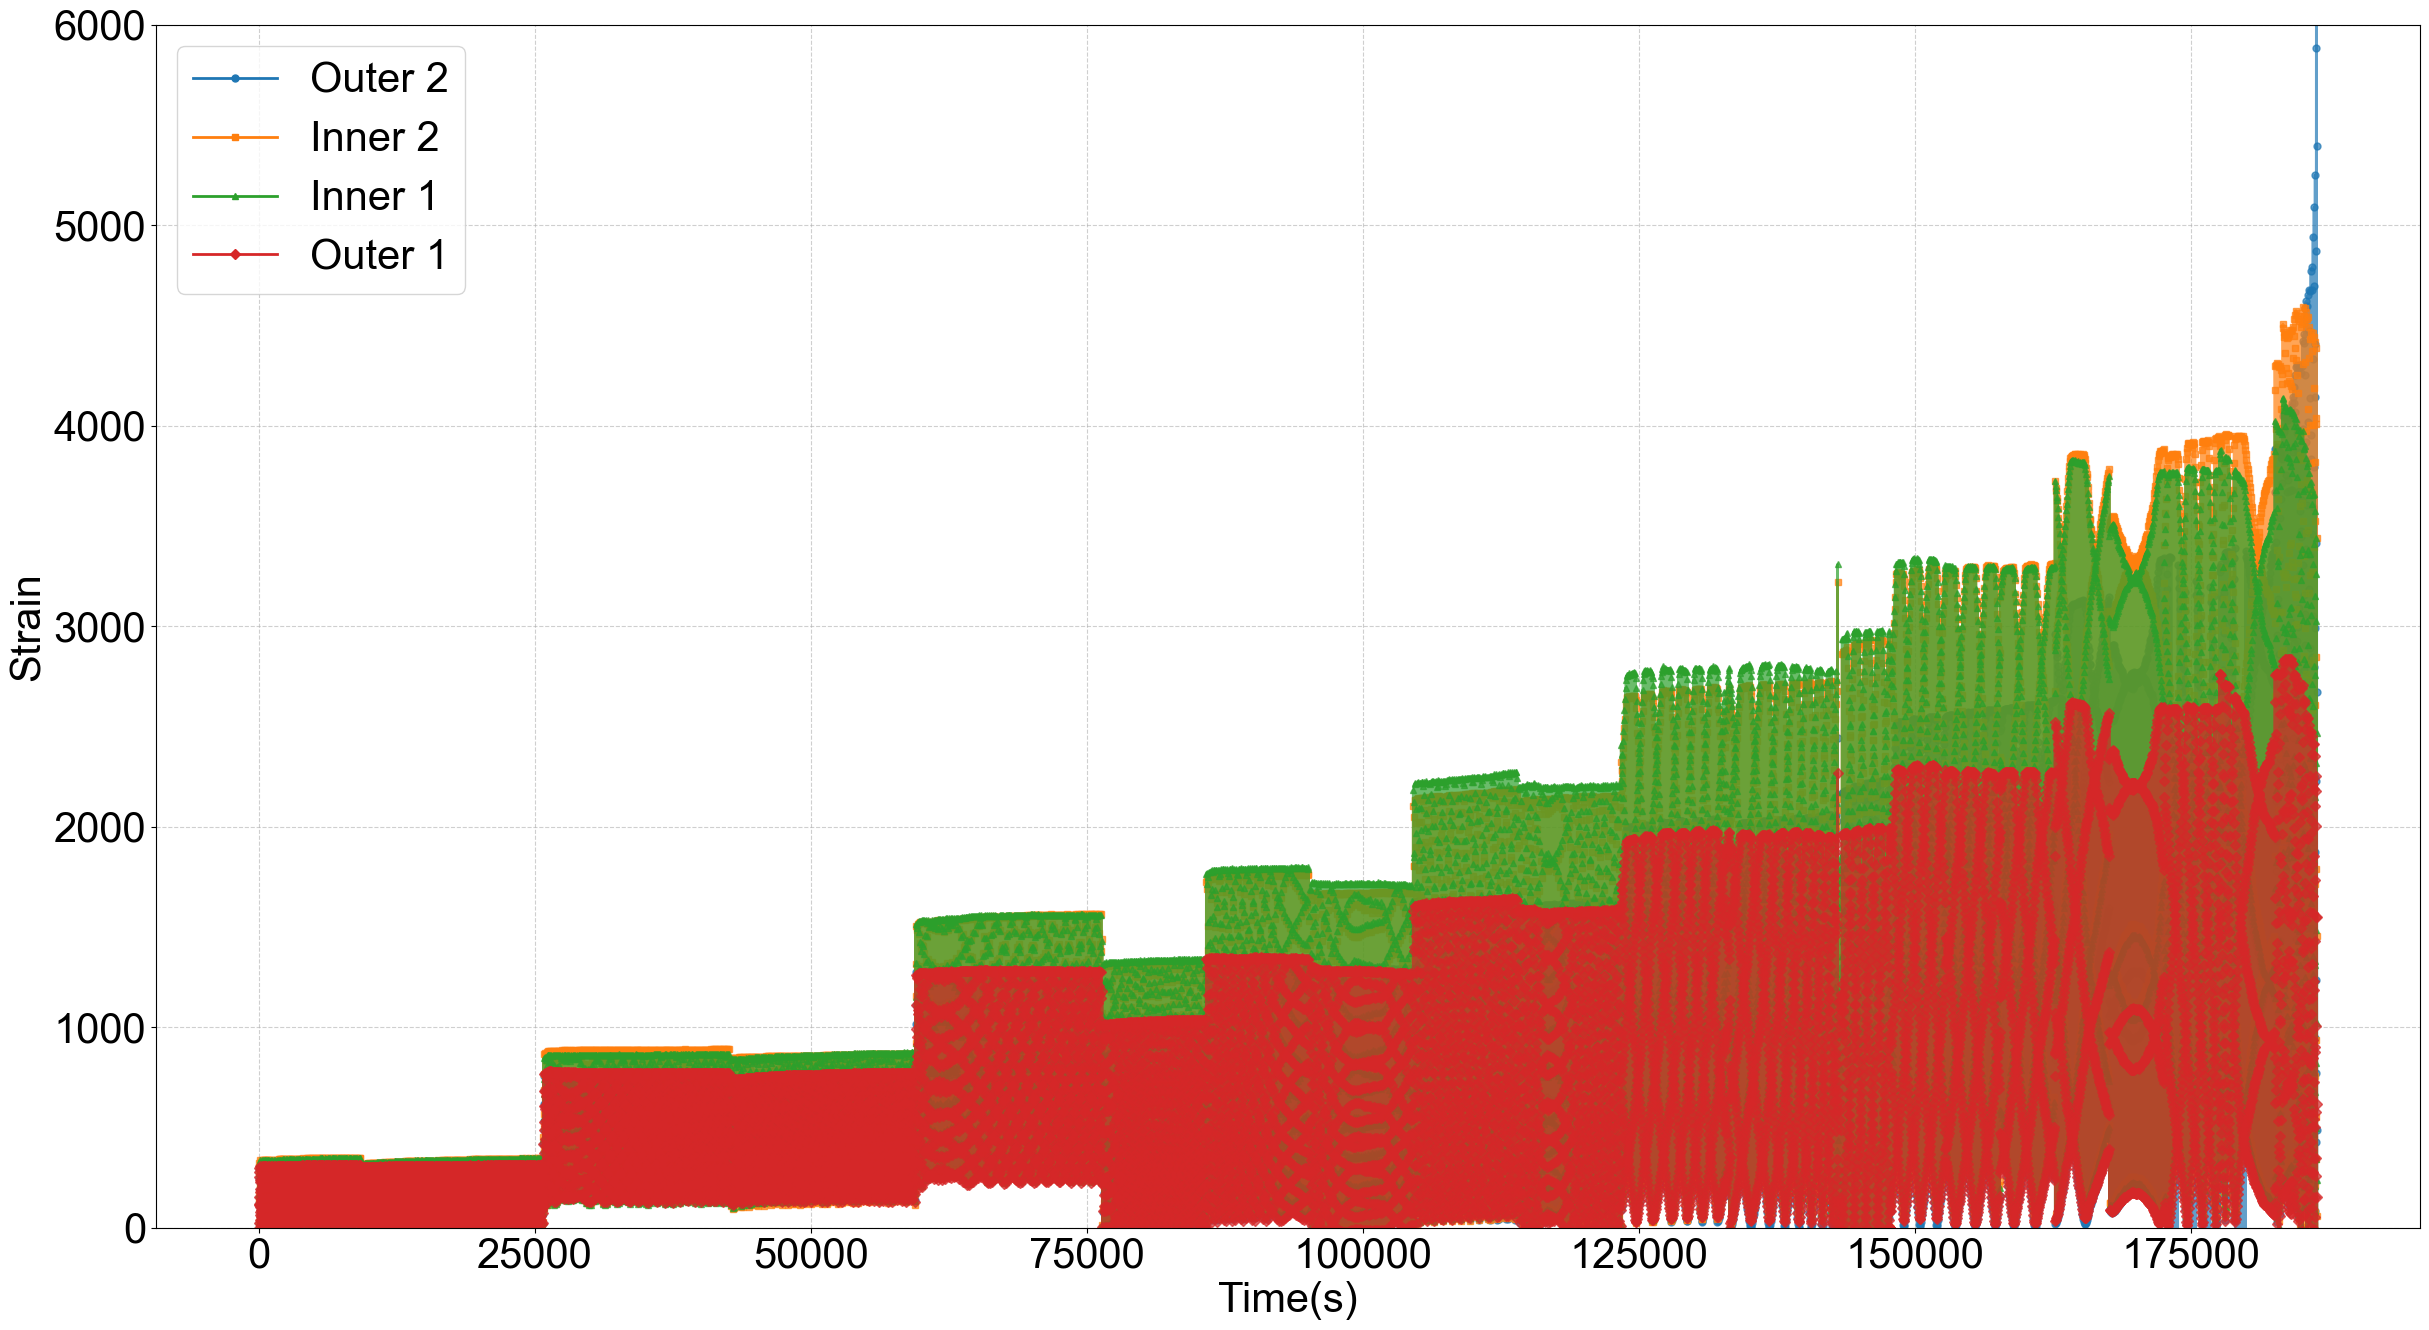

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- New Code Cell for Strain vs. Index Plot ---

print("--- Generating Strain vs. Sample Index Plot for FOD5 (s14-s17) ---")

# We assume 'process_stiffness_data' is defined in a previous cell, although not used here.

# Specify the target specimen and columns
specimen_to_plot = 'FOD6'
strain_columns_to_plot = ['s14', 's15', 's16', 's17']

df_strain_processed = None

# --- MODIFIED: Simplified data processing (no stiffness file needed) ---
# Step 1: Read and process the STRAIN file
strain_file = f"Data/Strain/Strains_{specimen_to_plot}.csv"
if not os.path.exists(strain_file):
    print(f"Error: Strain file not found for {specimen_to_plot}.")
else:
    try:
        # Read the CSV, assuming it has a header with column names
        df_strain = pd.read_csv(strain_file)
        
        if not all(col in df_strain.columns for col in strain_columns_to_plot):
            print(f"Error: Not all required columns {strain_columns_to_plot} were found in {strain_file}.")
        else:
            # Select only the columns we need
            df_strain_selected = df_strain[strain_columns_to_plot].copy()

            # Convert all selected columns to numeric
            for col in strain_columns_to_plot:
                df_strain_selected[col] = pd.to_numeric(df_strain_selected[col], errors='coerce')

            # Drop rows if ANY of the selected columns have NaN
            df_strain_selected.dropna(inplace=True)
            
            if df_strain_selected.empty:
                print(f"Warning: No valid strain data in the specified columns for {specimen_to_plot}.")
            else:
                # Reset index to ensure it's sequential after dropping rows
                df_strain_selected.reset_index(drop=True, inplace=True)
                df_strain_processed = df_strain_selected

    except Exception as e:
        print(f"Error reading or processing strain file {strain_file}: {e}")

# Step 2: Plot the processed data
if df_strain_processed is None:
    print("\nNo strain data was successfully processed to create a plot.")
else:
    # --- Plotting Section ---
    plt.figure(figsize=(25, 14))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    markers = ['o', 's', '^', 'D']
    
    legend_labels = {
        's14': 'Outer 2',
        's15': 'Inner 2',
        's16': 'Inner 1',
        's17': 'Outer 1'
    }
    
    # Loop through the specified columns to plot them individually
    for col, color, marker in zip(strain_columns_to_plot, colors, markers):
        # Thin data for plotting clarity
        filtered_plot_data = df_strain_processed.iloc[::10]
        
        # --- MODIFIED: Plot against the dataframe index ---
        plt.plot(filtered_plot_data.index, filtered_plot_data[col], 
                 marker=marker,
                 linestyle='-',
                 alpha=0.7,
                 markersize=5,
                 linewidth=2,
                 label=legend_labels.get(col, col),
                 color=color)

    # --- MODIFIED: Update labels and remove xlim ---
    plt.xlabel('Time(s)', fontsize=30)
    plt.ylabel('Strain', fontsize=30)
    plt.tick_params(axis='both', which='major', labelsize=30)
    
    plt.ylim(0, 6000)
    # xlim is removed to allow the plot to fit the full index range automatically
    
    plt.grid(True, linestyle='--', alpha=0.6)
    
    legend = plt.legend(fontsize=30, loc='upper left')
    for handle in legend.legend_handles:
        handle.set_alpha(1)
        
    plt.tight_layout()
    
    # Save the new figure with an updated name
    output_path_strain = f"Data/Strain/Figure_Strain_vs_Index_{specimen_to_plot}_specific_sensors.png"
    plt.savefig(output_path_strain, dpi=650, bbox_inches='tight')
    print(f"\nNew high-resolution strain plot saved to: {output_path_strain}")
    
    plt.show()

Calculating load cluster ranges from: Data/Stiffness_Reduction/MTSStiffness_exp_FOD5.csv


C:\Users\Giannis\AppData\Local\Temp\ipykernel_18140\3162234698.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('cividis', len(load_cluster_ranges))



Final high-resolution plot saved to: Data/Stiffness_Reduction/Figure_Stiffness_vs_Cycles_Final.png


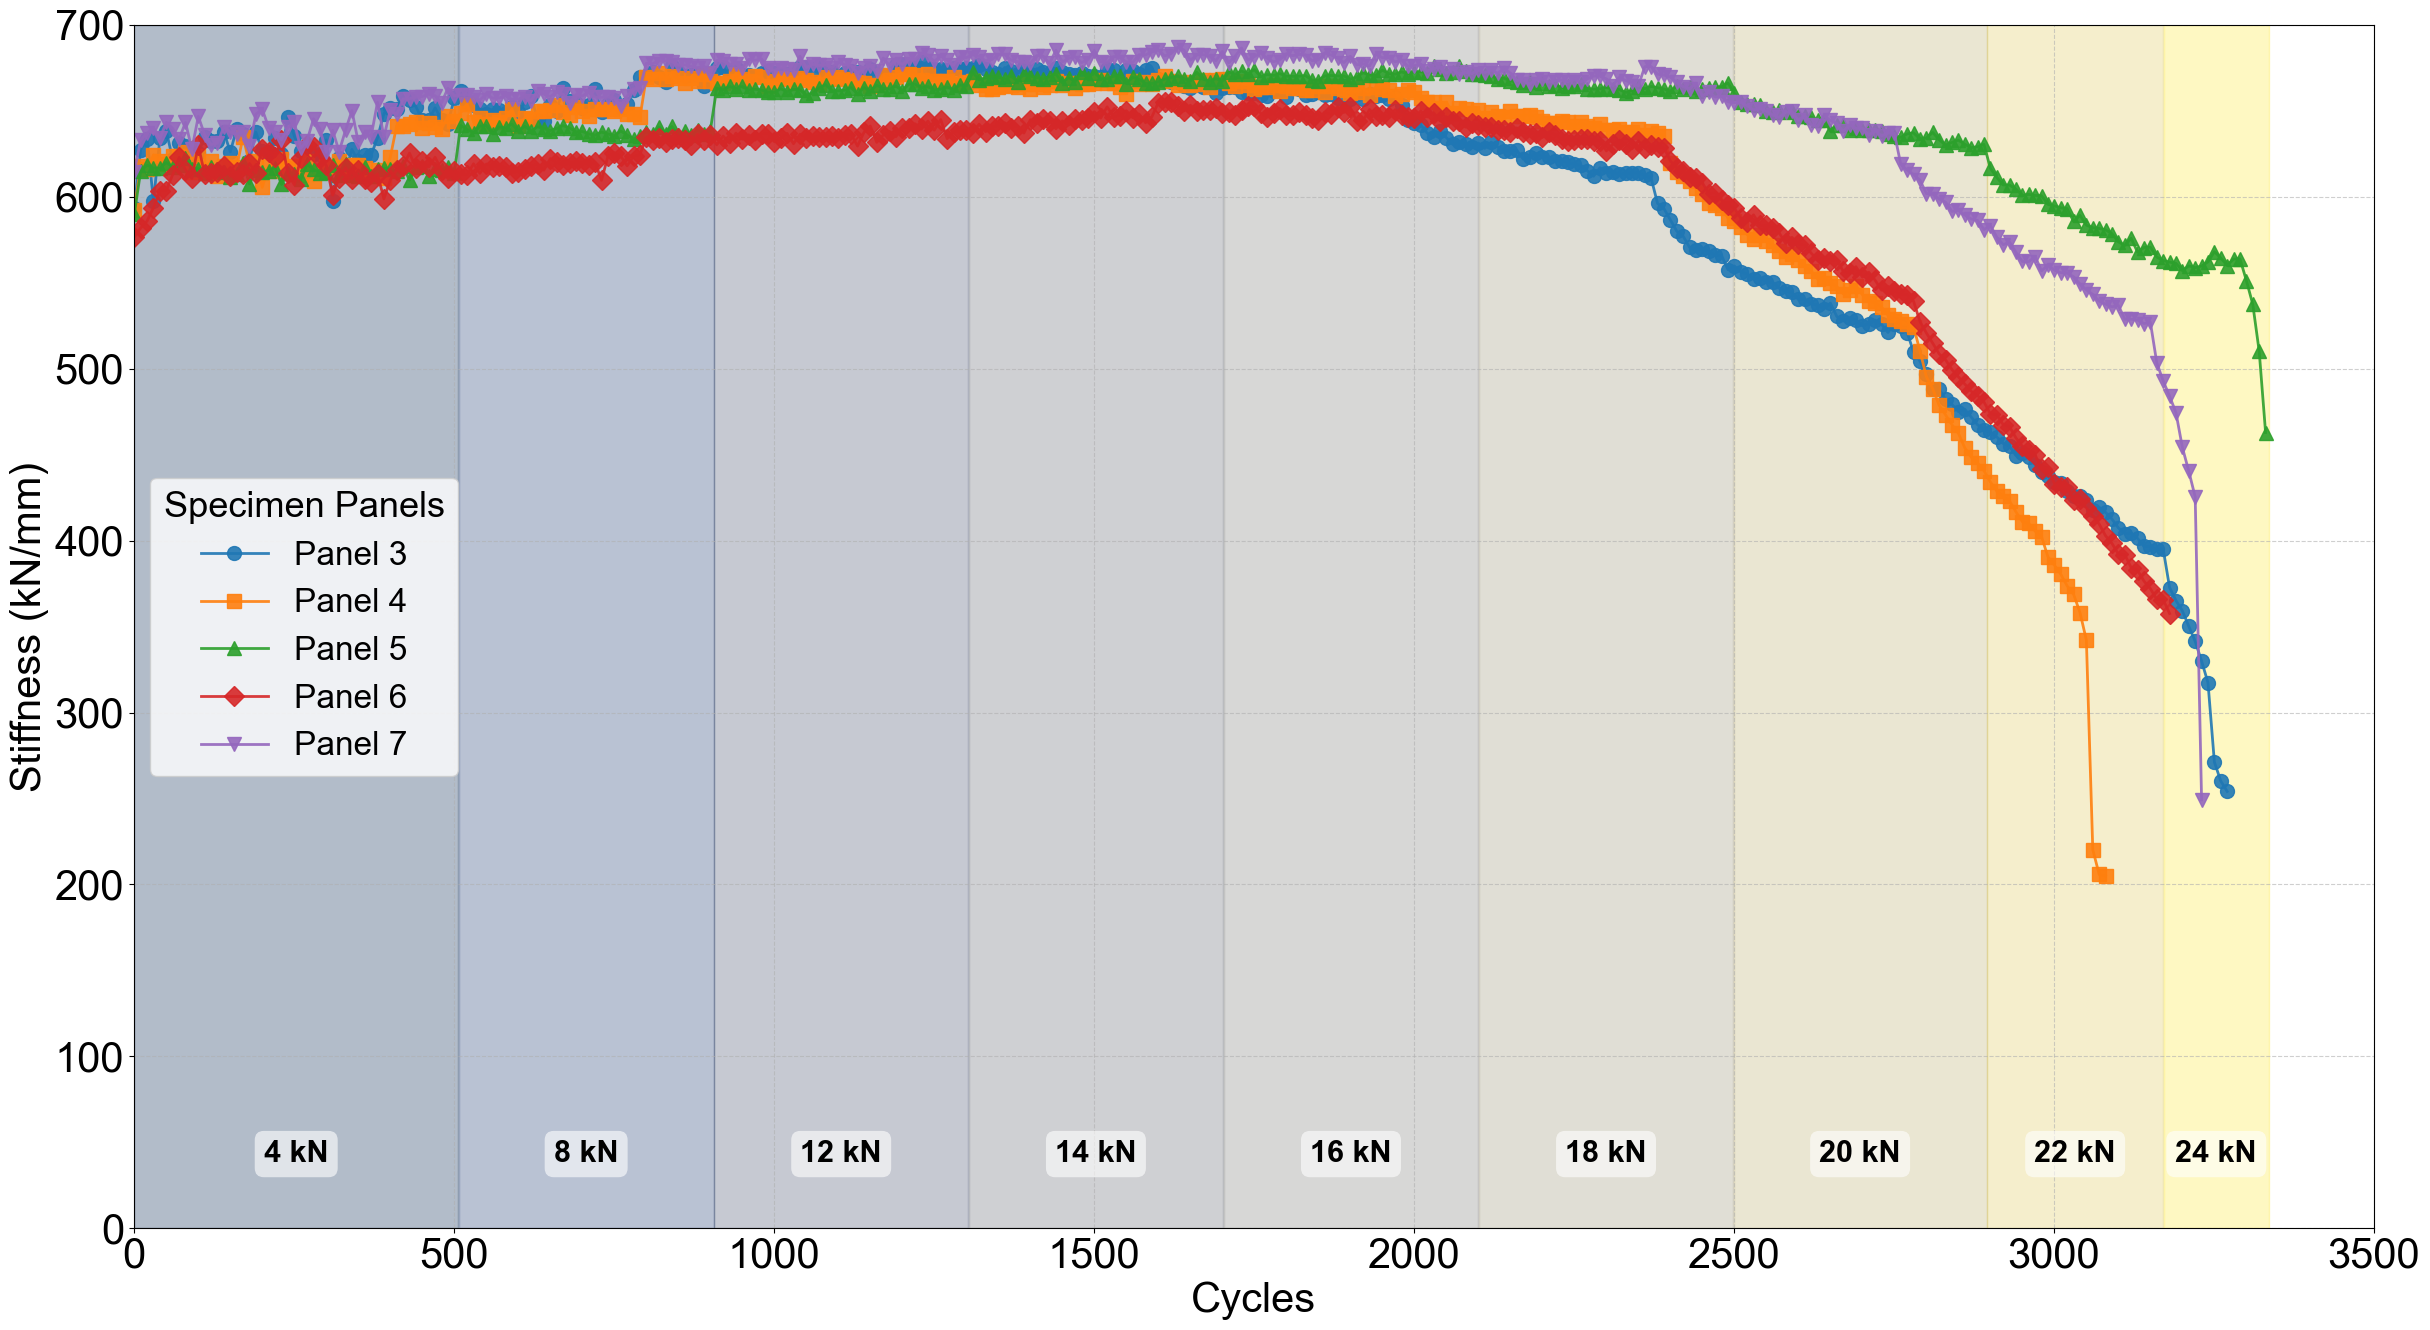

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Settings for High-Resolution Plot ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 30 # General font size for ticks, etc.

def process_stiffness_data(file_path):
    """Loads, cleans, and prepares stiffness data from a single file."""
    df = pd.read_csv(file_path)

    # Convert columns to numeric, turning errors into NaN
    df['Load'] = pd.to_numeric(df['Load'], errors='coerce')
    df['Stiffness'] = pd.to_numeric(df['Stiffness'], errors='coerce')

    # --- DATA CLEANING ---
    df.dropna(inplace=True)
    df = df[df['Stiffness'] > 0]
    df = df[df['Load'] >= 0]

    # Outlier Removal using the IQR method
    if not df.empty:
        Q1 = df['Stiffness'].quantile(0.01)
        Q3 = df['Stiffness'].quantile(0.99)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df['Stiffness'] >= lower_bound) & (df['Stiffness'] <= upper_bound)]

    if df.empty:
        return None, None

    # Use the dataframe index as the cycle number
    df.reset_index(drop=True, inplace=True)
    df['Cycle'] = df.index + 1

    initial_stiffness = df['Stiffness'].head(10).mean()

    return df, initial_stiffness

# --- Main Script ---
# List of files for the main plot
files = [
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD3.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD4.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD5.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD6.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD7.csv"
]

all_data = []
# Load data for all panels for line plotting
for file in files:
    if os.path.exists(file):
        specimen_name = os.path.basename(file).replace('.csv', '').replace('MTSStiffness_exp_', '')
        df, _ = process_stiffness_data(file)
        if df is not None:
            df['Specimen'] = specimen_name
            all_data.append(df)
    else:
        print(f"File not found: {file}")

if not all_data:
    print("\nNo data available to plot after cleaning.")
else:
    combined_df = pd.concat(all_data, ignore_index=True)

    # --- Calculate Load Cluster ranges based SOLELY on FOD5 data ---
    fod5_file_path = "Data/Stiffness_Reduction/MTSStiffness_exp_FOD5.csv"
    load_cluster_ranges = []

    if os.path.exists(fod5_file_path):
        print(f"Calculating load cluster ranges from: {fod5_file_path}")
        df_fod5, _ = process_stiffness_data(fod5_file_path)

        # The 9 distinct load steps to find
        load_steps = [4, 8, 12, 14, 16, 18, 20, 22, 24]

        # Group by the 'Load' column and find the min/max cycle for each group
        cycle_ranges_by_load = df_fod5.groupby('Load')['Cycle'].agg(['min', 'max'])

        # Create a list of dictionaries with the start and end cycles for each load step
        for load in load_steps:
            if load in cycle_ranges_by_load.index:
                min_cycle = cycle_ranges_by_load.loc[load]['min']
                max_cycle = cycle_ranges_by_load.loc[load]['max']
                load_cluster_ranges.append({
                    'load': load,
                    'start_cycle': min_cycle,
                    'end_cycle': max_cycle
                })
    else:
        print(f"Warning: {fod5_file_path} not found. Cannot create Load clusters.")

    # --- Plotting Section ---
    fig, ax = plt.subplots(figsize=(25, 14))

    # --- Draw vertical bands (without text for now) ---
    if load_cluster_ranges:
        colors = plt.cm.get_cmap('cividis', len(load_cluster_ranges))

        for i, cluster in enumerate(load_cluster_ranges):
            # Draw the band
            ax.axvspan(cluster['start_cycle'], cluster['end_cycle'],
                       color=colors(i),
                       alpha=0.3)

    # --- Plotting the specimen data ON TOP of the bands ---
    specimen_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    specimen_markers = ['o', 's', '^', 'D', 'v']

    unique_specimens = sorted(combined_df['Specimen'].unique())

    for i, (specimen, color, marker) in enumerate(zip(unique_specimens, specimen_colors, specimen_markers)):
        specimen_data = combined_df[combined_df['Specimen'] == specimen]
        filtered_data = specimen_data.iloc[::10]

        panel_label = f"Panel {specimen.replace('FOD', '')}"

        ax.plot(filtered_data['Cycle'], filtered_data['Stiffness'],
                 marker=marker,
                 linestyle='-',
                 color=color,
                 alpha=0.9,
                 markersize=10,
                 linewidth=2,
                 label=panel_label)

    # --- Plot Customization (SET AXES FIRST) ---
    ax.set_xlabel('Cycles', fontsize=30)
    ax.set_ylabel('Stiffness (kN/mm)', fontsize=30)
    ax.set_xlim(0, 3500)
    ax.set_ylim(0, 700) # This must be set before calculating text position
    ax.tick_params(axis='both', which='major', labelsize=30)
    ax.grid(True, linestyle='--', alpha=0.6, which='both')

    # --- Add text labels AFTER axes are finalized ---
    if load_cluster_ranges:
        for cluster in load_cluster_ranges:
            band_center_x = (cluster['start_cycle'] + cluster['end_cycle']) / 2
            
            # ---MODIFIED: Calculate y-position for the bottom of the plot---
            ymin, ymax = ax.get_ylim()
            text_y_position = ymin + (ymax - ymin) * 0.05 # Position at 5% from the bottom

            ax.text(band_center_x, text_y_position, f"{cluster['load']} kN",
                    color='black',
                    fontsize=22,
                    ha='center', 
                    va='bottom', # ---MODIFIED: Align the bottom of the text box to the y-position---
                    weight='bold',
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.3'))

    # --- Legend and Layout ---
    # ---MODIFIED: Moved legend to the center left---
    ax.legend(fontsize=24, title_fontsize=26, title='Specimen Panels', loc='center left')
    
    plt.tight_layout()

    # --- Saving the Figure ---
    output_path = "Data/Stiffness_Reduction/Figure_Stiffness_vs_Cycles_Final.png"
    plt.savefig(output_path, dpi=650, bbox_inches='tight')
    print(f"\nFinal high-resolution plot saved to: {output_path}")

    plt.show()

--- Generating Strain vs. Cycles Plot for FOD7 with 350-Cycle Bands ---

New high-resolution strain plot with 350-cycle bands saved to: Data/Strain/Figure_Strain_vs_Cycles_FOD7_with_350_bands.png


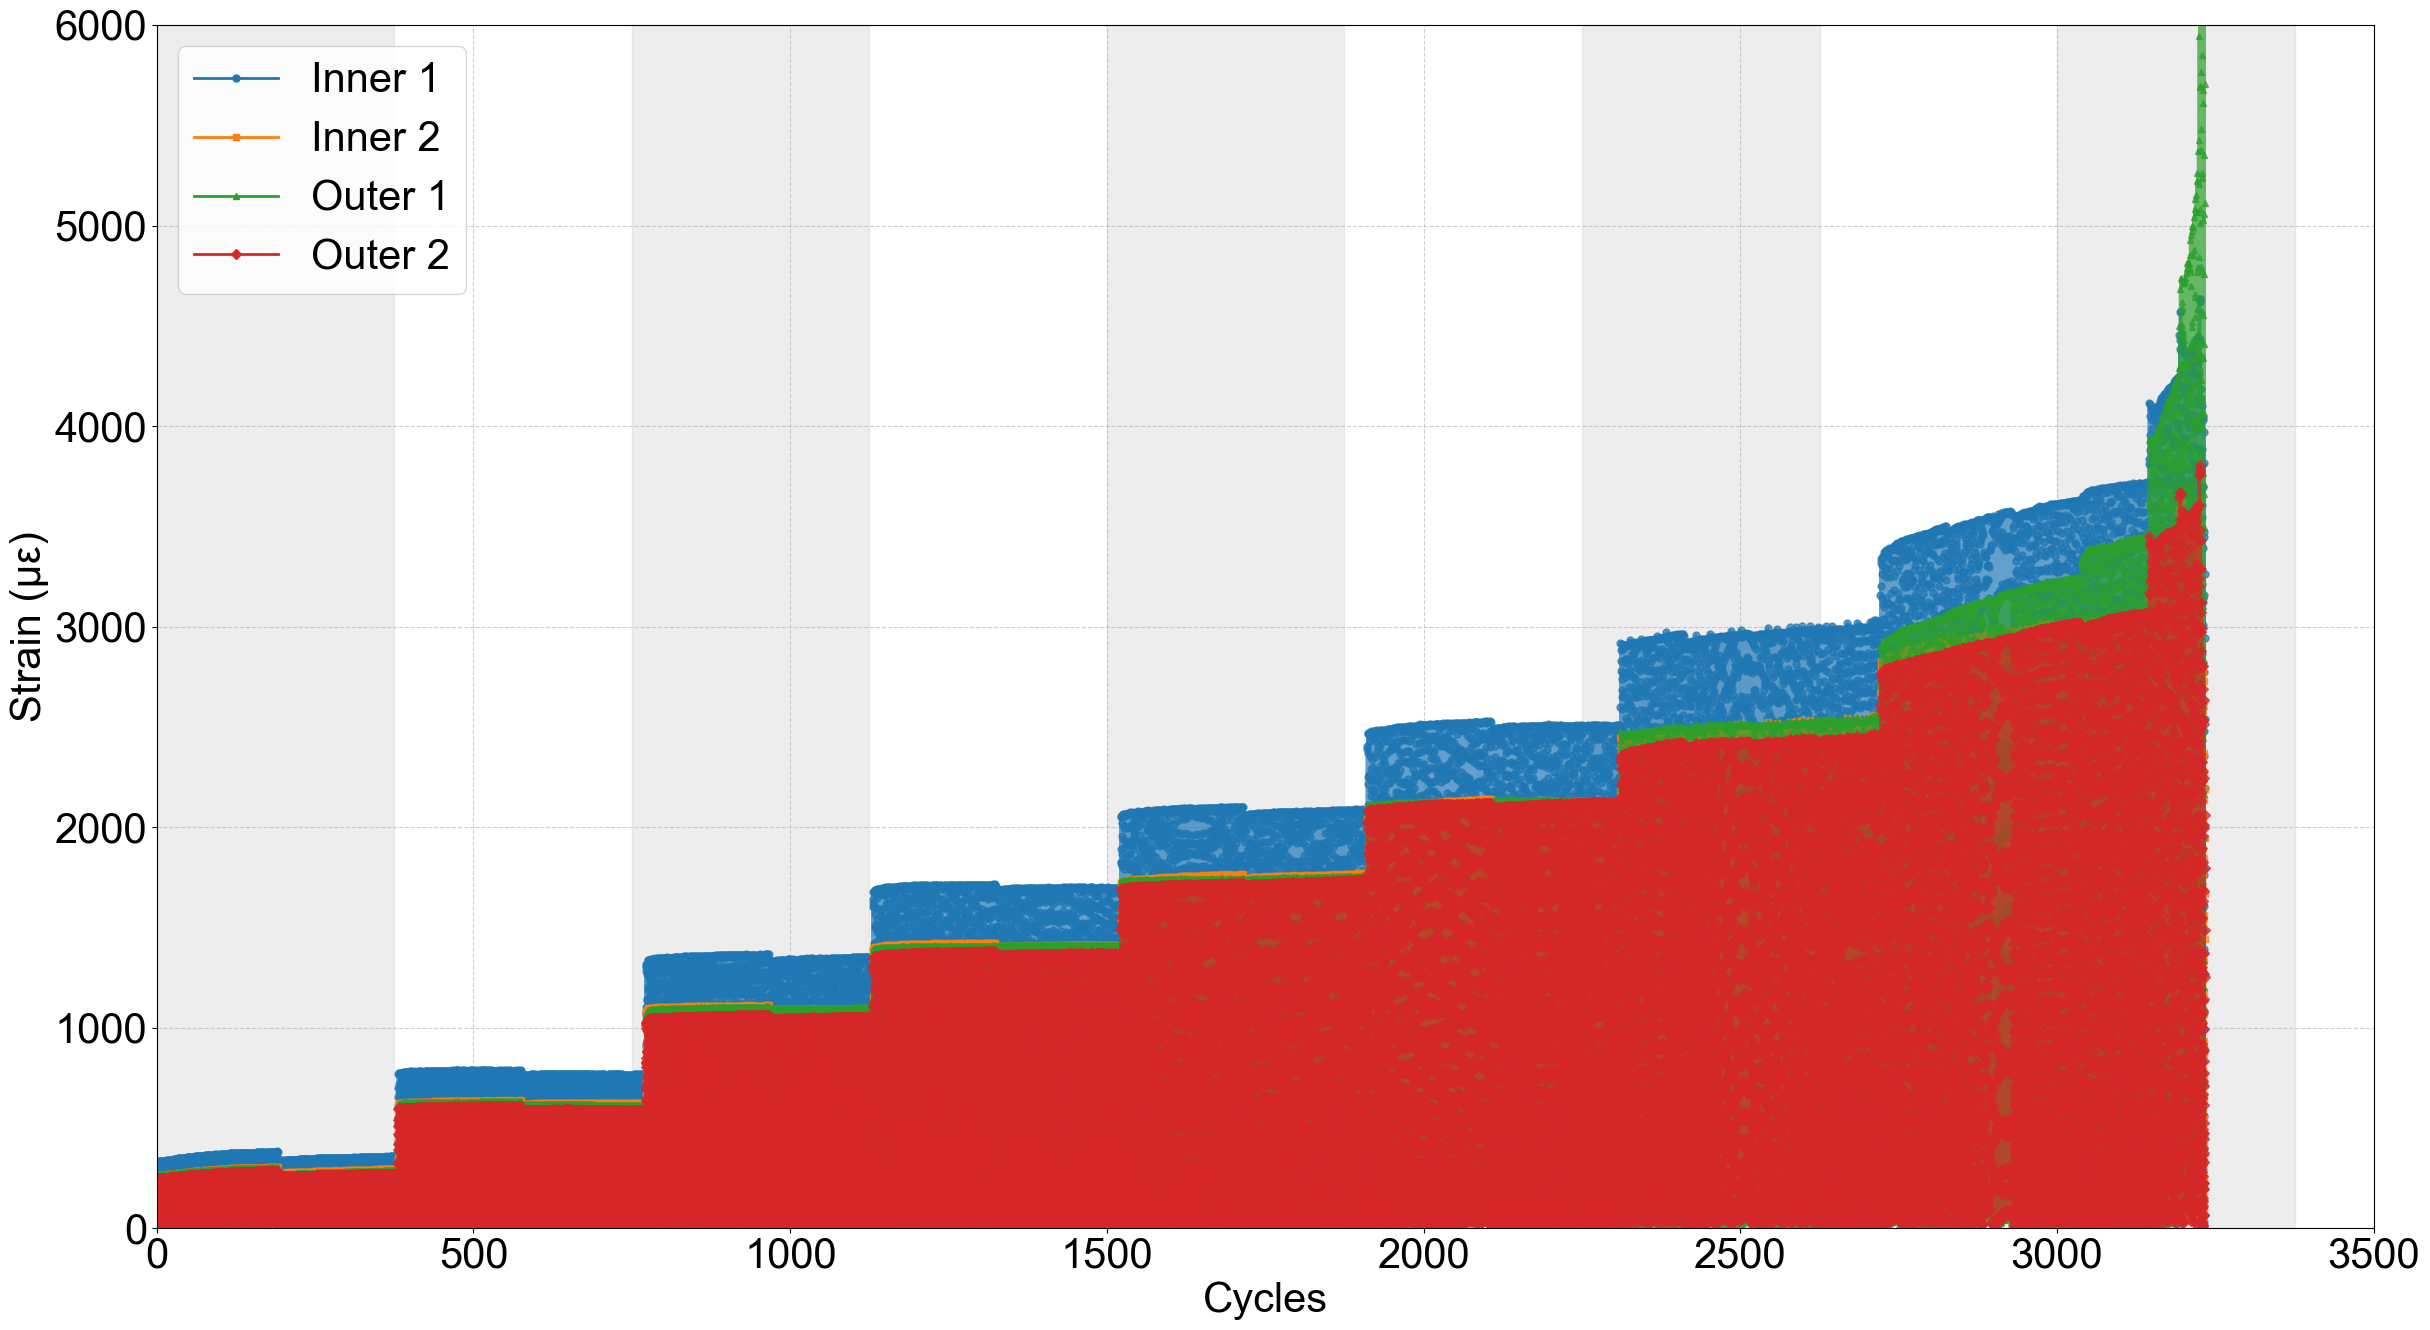

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Settings for High-Resolution Plot ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 30 # General font size for ticks, etc.

# Define a process_stiffness_data function if it's not already in your environment
def process_stiffness_data(file_path):
    """Loads, cleans, and prepares stiffness data from a single file."""
    df = pd.read_csv(file_path)
    df['Load'] = pd.to_numeric(df['Load'], errors='coerce')
    df['Stiffness'] = pd.to_numeric(df['Stiffness'], errors='coerce')
    df.dropna(inplace=True)
    df = df[df['Stiffness'] > 0]
    df = df[df['Load'] >= 0]
    if not df.empty:
        Q1 = df['Stiffness'].quantile(0.01)
        Q3 = df['Stiffness'].quantile(0.99)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df['Stiffness'] >= lower_bound) & (df['Stiffness'] <= upper_bound)]
    if df.empty:
        return None, None
    df.reset_index(drop=True, inplace=True)
    df['Cycle'] = df.index + 1
    initial_stiffness = df['Stiffness'].head(10).mean()
    return df, initial_stiffness


print("--- Generating Strain vs. Cycles Plot for FOD7 with 350-Cycle Bands ---")

# Specify the target specimen and columns
specimen_to_plot = 'FOD7'
strain_columns_to_plot = ['s13', 's14', 's15', 's16'] # These are the columns to load

df_strain_processed = None

# Step 1: Get the final cycle count from the STIFFNESS file
stiffness_file = f"Data/Stiffness_Reduction/MTSStiffness_exp_{specimen_to_plot}.csv"

if not os.path.exists(stiffness_file):
    print(f"Error: Stiffness file not found for {specimen_to_plot}. Cannot proceed.")
else:
    df_stiffness, _ = process_stiffness_data(stiffness_file)
    if df_stiffness is None:
        print(f"Error: Could not process stiffness data for {specimen_to_plot}.")
    else:
        final_cycle_count = len(df_stiffness)

        # Step 2: Read and process the corresponding STRAIN file
        strain_file = f"Data/Strain/Strains_{specimen_to_plot}.csv"
        if not os.path.exists(strain_file):
            print(f"Error: Strain file not found for {specimen_to_plot}.")
        else:
            try:
                df_strain = pd.read_csv(strain_file)
                
                if not all(col in df_strain.columns for col in strain_columns_to_plot):
                    print(f"Error: Not all required columns {strain_columns_to_plot} were found in {strain_file}.")
                else:
                    df_strain_selected = df_strain[strain_columns_to_plot].copy()

                    for col in strain_columns_to_plot:
                        df_strain_selected[col] = pd.to_numeric(df_strain_selected[col], errors='coerce')

                    df_strain_selected.dropna(inplace=True)
                    
                    if df_strain_selected.empty:
                        print(f"Warning: No valid strain data in the specified columns for {specimen_to_plot}.")
                    else:
                        # Step 3: Create the 'Cycle' axis for the strain data
                        num_strain_points = len(df_strain_selected)
                        df_strain_selected['Cycle'] = np.linspace(start=1, stop=final_cycle_count, num=num_strain_points)
                        df_strain_processed = df_strain_selected

            except Exception as e:
                print(f"Error reading or processing strain file {strain_file}: {e}")

# Step 4: Plot the processed data
if df_strain_processed is None:
    print("\nNo strain data was successfully processed to create a plot.")
else:
    # --- Plotting Section ---
    plt.figure(figsize=(25, 14))
    
    # --- MODIFIED: Draw alternating vertical bands every 350 cycles ---
    x_limit = 3500
    band_lim =375
    # Step by 700 (350 for the band + 350 for the gap)
    for i in np.arange(0, x_limit, 2*band_lim):
        # Draw a grey band from i to i+350
        plt.axvspan(i, i + band_lim, color='lightgrey', alpha=0.4, zorder=0)

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red
    markers = ['o', 's', '^', 'D']
    
    legend_labels = {
        's13': 'Outer 2',
        's14': 'Inner 2',
        's15': 'Inner 1',
        's16': 'Outer 1'
    }

    # Use the specific plotting order
    plot_order = ['s15', 's14', 's16', 's13']
    
    # Loop through the 'plot_order' list to control the sequence
    for col, color, marker in zip(plot_order, colors, markers):
        filtered_plot_data = df_strain_processed.iloc[::5]
        
        plt.plot(filtered_plot_data['Cycle'], filtered_plot_data[col], 
                 marker=marker,
                 linestyle='-',
                 alpha=0.7,
                 markersize=5,
                 linewidth=2,
                 label=legend_labels.get(col, col),
                 color=color)

    # Apply high-resolution formatting
    plt.xlabel('Cycles', fontsize=30)
    plt.ylabel('Strain (με)', fontsize=30)
    plt.tick_params(axis='both', which='major', labelsize=30)
    
    plt.ylim(0, 6000)
    plt.xlim(0, x_limit)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    
    legend = plt.legend(fontsize=30, loc='upper left')
    for handle in legend.legend_handles:
        handle.set_alpha(1)
        
    plt.tight_layout()
    
    # Save the new figure
    output_path_strain = f"Data/Strain/Figure_Strain_vs_Cycles_{specimen_to_plot}_with_350_bands.png"
    plt.savefig(output_path_strain, dpi=650, bbox_inches='tight')
    print(f"\nNew high-resolution strain plot with 350-cycle bands saved to: {output_path_strain}")
    
    plt.show()

C:\Users\Giannis\AppData\Local\Temp\ipykernel_18140\1701740907.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('cividis', len(load_cluster_ranges))



Final high-resolution plot saved to: Data/Stiffness_Reduction/Figure_Stiffness_vs_Cycles_Final.png


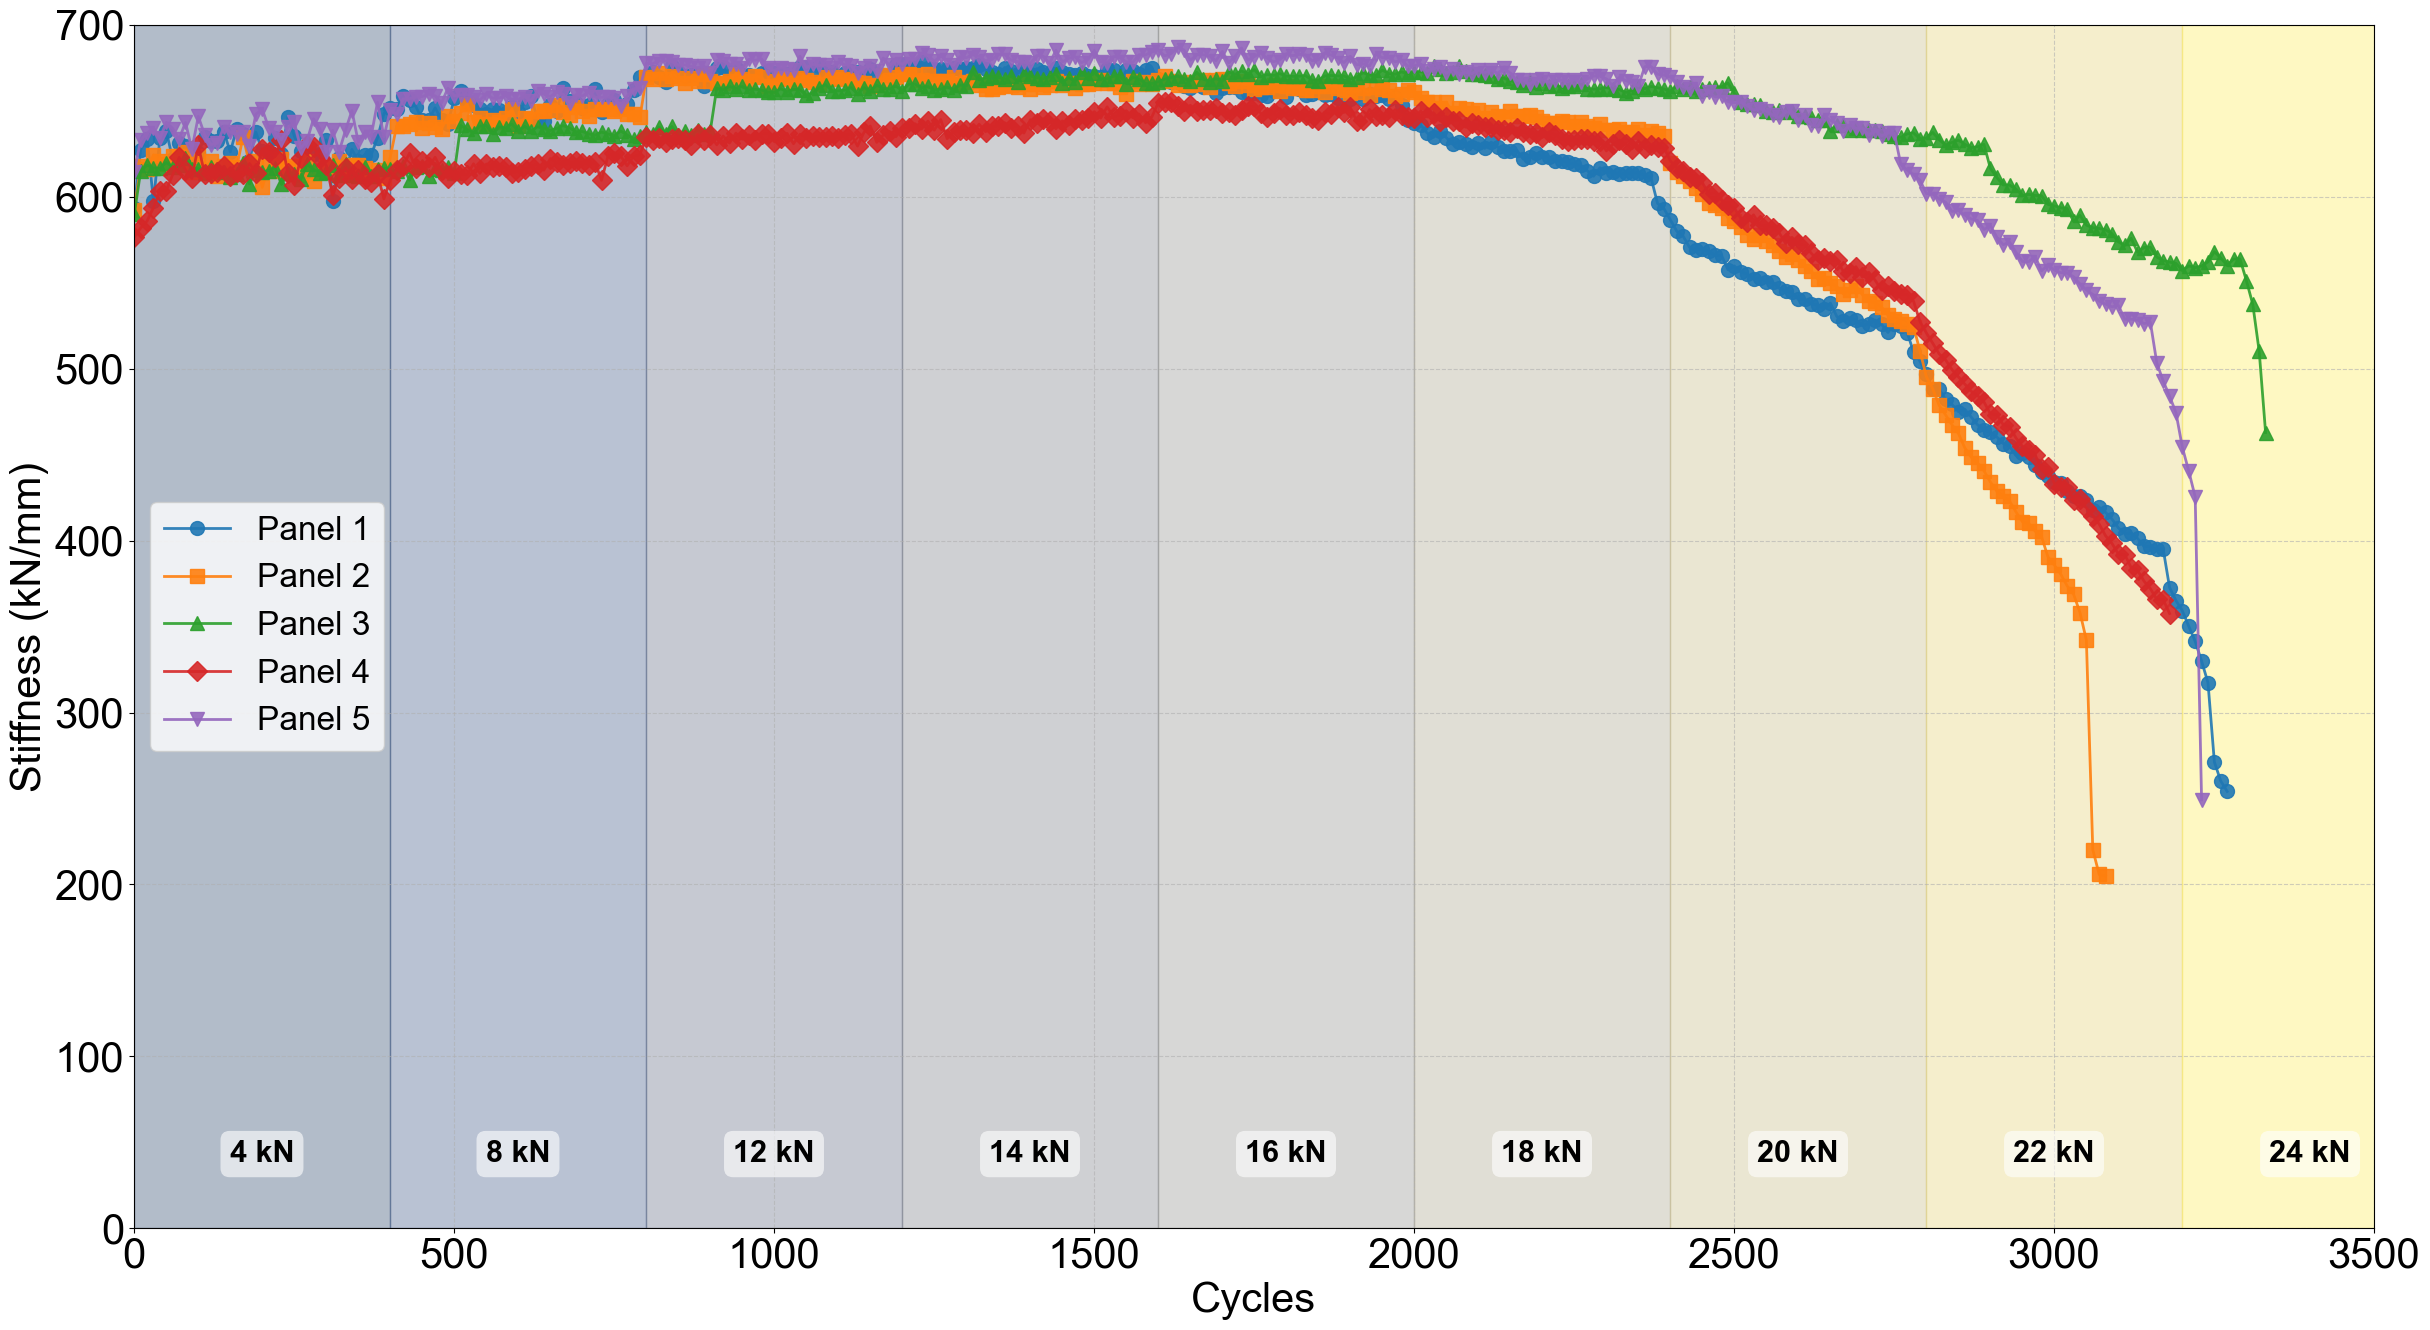

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Settings for High-Resolution Plot ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 30 # General font size for ticks, etc.

def process_stiffness_data(file_path):
    """Loads, cleans, and prepares stiffness data from a single file."""
    df = pd.read_csv(file_path)

    # Convert columns to numeric, turning errors into NaN
    df['Load'] = pd.to_numeric(df['Load'], errors='coerce')
    df['Stiffness'] = pd.to_numeric(df['Stiffness'], errors='coerce')

    # --- DATA CLEANING ---
    df.dropna(inplace=True)
    df = df[df['Stiffness'] > 0]
    df = df[df['Load'] >= 0]

    # Outlier Removal using the IQR method
    if not df.empty:
        Q1 = df['Stiffness'].quantile(0.01)
        Q3 = df['Stiffness'].quantile(0.99)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df['Stiffness'] >= lower_bound) & (df['Stiffness'] <= upper_bound)]

    if df.empty:
        return None, None

    # Use the dataframe index as the cycle number
    df.reset_index(drop=True, inplace=True)
    df['Cycle'] = df.index + 1

    initial_stiffness = df['Stiffness'].head(10).mean()

    return df, initial_stiffness

# --- Main Script ---
# List of files for the main plot
files = [
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD3.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD4.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD5.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD6.csv",
    "Data/Stiffness_Reduction/MTSStiffness_exp_FOD7.csv"
]

all_data = []
# Load data for all panels for line plotting
for file in files:
    if os.path.exists(file):
        specimen_name = os.path.basename(file).replace('.csv', '').replace('MTSStiffness_exp_', '')
        df, _ = process_stiffness_data(file)
        if df is not None:
            df['Specimen'] = specimen_name
            all_data.append(df)
    else:
        print(f"File not found: {file}")

if not all_data:
    print("\nNo data available to plot after cleaning.")
else:
    combined_df = pd.concat(all_data, ignore_index=True)

    # --- MODIFIED SECTION: Manually define Load Cluster ranges ---
    # The ranges are now fixed at 400 cycles per load step.
    load_cluster_ranges = []
    load_steps = [4, 8, 12, 14, 16, 18, 20, 22, 24]
    cycles_per_step = 400
    current_cycle = 1

    for load in load_steps:
        start_cycle = current_cycle
        end_cycle = current_cycle + cycles_per_step - 1
        load_cluster_ranges.append({
            'load': load,
            'start_cycle': start_cycle,
            'end_cycle': end_cycle
        })
        current_cycle = end_cycle + 1 # Set the start for the next step

    # --- Plotting Section ---
    fig, ax = plt.subplots(figsize=(25, 14))

    # --- Draw vertical bands (without text for now) ---
    if load_cluster_ranges:
        colors = plt.cm.get_cmap('cividis', len(load_cluster_ranges))

        for i, cluster in enumerate(load_cluster_ranges):
            # Draw the band
            ax.axvspan(cluster['start_cycle'], cluster['end_cycle'],
                       color=colors(i),
                       alpha=0.3)

    # --- Plotting the specimen data ON TOP of the bands ---
    specimen_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    specimen_markers = ['o', 's', '^', 'D', 'v']

    unique_specimens = sorted(combined_df['Specimen'].unique())

    for i, (specimen, color, marker) in enumerate(zip(unique_specimens, specimen_colors, specimen_markers)):
        specimen_data = combined_df[combined_df['Specimen'] == specimen]
        filtered_data = specimen_data.iloc[::10]

        # --- THIS IS THE MODIFIED LINE ---
        panel_label = f"Panel {i + 1}"

        ax.plot(filtered_data['Cycle'], filtered_data['Stiffness'],
                marker=marker,
                linestyle='-',
                color=color,
                alpha=0.9,
                markersize=10,
                linewidth=2,
                label=panel_label)

    # --- Plot Customization (SET AXES FIRST) ---
    ax.set_xlabel('Cycles', fontsize=30)
    ax.set_ylabel('Stiffness (kN/mm)', fontsize=30)
    ax.set_xlim(0, 3500)
    ax.set_ylim(0, 700) # This must be set before calculating text position
    ax.tick_params(axis='both', which='major', labelsize=30)
    ax.grid(True, linestyle='--', alpha=0.6, which='both')


    # --- Add text labels AFTER axes are finalized ---
    if load_cluster_ranges:
        for cluster in load_cluster_ranges:
            band_center_x = (cluster['start_cycle'] + cluster['end_cycle']) / 2
            
            # ---MODIFIED: Calculate y-position for the bottom of the plot---
            ymin, ymax = ax.get_ylim()
            text_y_position = ymin + (ymax - ymin) * 0.05 # Position at 5% from the bottom

            ax.text(band_center_x, text_y_position, f"{cluster['load']} kN",
                    color='black',
                    fontsize=22,
                    ha='center', 
                    va='bottom', # ---MODIFIED: Align the bottom of the text box to the y-position---
                    weight='bold',
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.3'))

    # --- Legend and Layout ---
    # ---MODIFIED: Moved legend to the center left---
    ax.legend(fontsize=24, title_fontsize=26, loc='center left')
    
    plt.tight_layout()

    # --- Saving the Figure ---
    output_path = "Data/Stiffness_Reduction/Figure_Stiffness_vs_Cycles_Final.png"
    plt.savefig(output_path, dpi=650, bbox_inches='tight')
    print(f"\nFinal high-resolution plot saved to: {output_path}")

    plt.show()